# Chapter 1: Fundamentals -- Worked in Python

**A computational companion to Chapter 1 of Johnson & Graham, *High-Speed Digital Design: A Handbook of Black Magic*.**

The organizing claim of the chapter is that **rise time, not clock frequency, sets everything else**.
A 10 MHz board with 500 ps edges is a high-speed board. This notebook takes the formulas from the
chapter, computes them, plots them, and checks the worked examples in the lecture notes against the
arithmetic.

Every number below is computed live from the parameter block in the next cell. Change the parameters
and every table, plot and printed value updates.

**Contents**

| Section | Topic | Key result |
|---|---|---|
| 1 | Spectrum of a trapezoid | Two breakpoints: $1/\pi\tau$ and $1/\pi T_r$ |
| 2 | Knee frequency | $F_{knee}=0.5/T_r$, and how it differs from $F_{3dB}=0.35/T_r$ |
| 3 | Time and distance | $v=c/\sqrt{\varepsilon_{r,eff}}$, edge length $l=T_r v$ |
| 4 | Lumped vs distributed | $L_{crit}=T_r v/6$, and where the 6 comes from |
| 5 | The four reactances | $X_C=T_r/\pi C$, $X_L=\pi L/T_r$ |
| 6 | Self capacitance | $I=C\,dV/dt$, $T_r=2.2RC$ |
| 7 | Self inductance | $V=L\,dI/dt$, ground bounce, decoupling |
| 8 | Mutual C and L | Crosstalk, and which mechanism dominates |
| 9 | NEXT vs FEXT | Saturation, and why stripline kills FEXT |
| 10 | Losses | Skin effect, dielectric loss, surface roughness |
| 11 | Rise-time budget | RSS combination and measurement error |
| 12 | Lab jigs | The area method for inductance |
| 13 | Board review | A calculator that runs the whole chapter at once |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.ticker as mticker

plt.rcParams.update({
    'figure.figsize': (9, 4.8),
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.28,
    'axes.axisbelow': True,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'legend.framealpha': 0.92,
})

# A consistent palette used throughout
CB  = '#2b6cb0'   # primary blue
CR  = '#c53030'   # alert red
CG  = '#2f855a'   # ok green
CO  = '#dd6b20'   # orange
CP  = '#6b46c1'   # purple
CGY = '#4a5568'   # grey

# ---------------- physical constants ----------------
c_in_ns = 11.8          # speed of light, inches per nanosecond
c_m_s   = 2.998e8       # m/s
mu0     = 4e-7*np.pi    # H/m
rho_cu  = 1.72e-8       # ohm-m, annealed copper
eps0    = 8.854e-12

MIL = 25.4e-6           # 1 mil in metres
IN  = 25.4e-3           # 1 inch in metres

def sinc(x):
    # normalised sinc: sin(pi x)/(pi x), sinc(0) = 1
    return np.sinc(x)

def to_db(x, floor=1e-12):
    return 20*np.log10(np.maximum(np.abs(x), floor))

def rise_time_10_90(t, v):
    # 10-90% rise time of a rising step, by linear interpolation
    v0, v1 = v[0], v[-1]
    def cross(level):
        idx = int(np.argmax(v >= level))
        if idx == 0:
            return t[0]
        x0, x1, y0, y1 = t[idx-1], t[idx], v[idx-1], v[idx]
        return x0 + (level-y0)*(x1-x0)/(y1-y0)
    return cross(v0 + 0.9*(v1-v0)) - cross(v0 + 0.1*(v1-v0))

def table(rows, headers, title=None):
    cols = list(zip(*([headers] + [[str(x) for x in r] for r in rows])))
    w = [max(len(str(x)) for x in col) for col in cols]
    rule = '  '.join('-'*wi for wi in w)
    if title:
        print(title)
        print('=' * len(rule))
    print('  '.join(str(h).ljust(wi) for h, wi in zip(headers, w)))
    print(rule)
    for r in rows:
        print('  '.join(str(x).ljust(wi) for x, wi in zip(r, w)))
    print()

print('environment ready')

environment ready


## Design parameter block

Everything downstream reads from here. These defaults describe a generic 4-layer FR-4 board driven by
fast CMOS; swap them for your own stackup and the whole notebook re-derives itself.

In [2]:
# ============================================================
#  BOARD AND SIGNAL PARAMETERS
# ============================================================

# --- edge rates of interest (10-90% rise time, nanoseconds) ---
LOGIC_FAMILIES = {
    'Standard TTL':   5.0,
    'LS TTL':         2.0,
    'Fast CMOS':      1.0,
    'ACT / LVCMOS':   0.6,
    'LVDS':           0.3,
    'DDR4 (~100 ps)': 0.10,
    'SerDes PAM4':    0.03,
}

Tr_ns  = 1.0     # the design edge for worked examples: fast CMOS, 1 ns
Vswing = 3.3     # V, logic swing
Z0     = 50.0    # ohm, nominal single-ended trace impedance
Rdrv   = 30.0    # ohm, driver output impedance

# --- dielectric / stackup ---
er_bulk       = 4.3    # FR-4 bulk relative permittivity
er_eff_ustrip = 3.1    # microstrip effective permittivity (fields split FR-4 / air)
er_alumina    = 10.0
tan_d         = 0.020  # FR-4 loss tangent near 1 GHz
h_mil         = 5.0    # dielectric height under the trace, mils
w_mil         = 5.0    # trace width, mils
t_cu_um       = 35.0   # 1 oz copper thickness, microns
Rq_um         = 2.0    # RMS surface roughness of HTE foil, microns

# --- parasitics used in the worked examples ---
C_load_pF  = 10.0   # receiver + package + via load capacitance
L_gnd_nH   = 5.0    # legacy DIP / QFP ground lead inductance
L_ball_nH  = 0.5    # one BGA ground ball
L_mount_nH = 1.5    # decoupling capacitor mounting loop inductance
C_decap_nF = 100.0

# --- derived velocities (inches per nanosecond) ---
v_stripline  = c_in_ns/np.sqrt(er_bulk)
v_microstrip = c_in_ns/np.sqrt(er_eff_ustrip)
D_stripline  = 1000.0/v_stripline     # ps per inch
D_microstrip = 1000.0/v_microstrip

MEDIA = {
    'Air / free space':        (1.0,           c_in_ns),
    'Coax (VF 0.75)':          (1/0.75**2,     c_in_ns*0.75),
    'Coax (VF 0.66)':          (1/0.66**2,     c_in_ns*0.66),
    'FR-4 microstrip (outer)': (er_eff_ustrip, v_microstrip),
    'FR-4 stripline (inner)':  (er_bulk,       v_stripline),
    'Alumina stripline':       (er_alumina,    c_in_ns/np.sqrt(er_alumina)),
}

print(f"Design edge          Tr = {Tr_ns*1000:.0f} ps")
print(f"Stripline velocity        {v_stripline:.2f} in/ns   -> {D_stripline:.0f} ps/in")
print(f"Microstrip velocity       {v_microstrip:.2f} in/ns   -> {D_microstrip:.0f} ps/in")
print(f"Microstrip is {100*(v_microstrip/v_stripline - 1):.0f}% faster than stripline on the same board.")

Design edge          Tr = 1000 ps
Stripline velocity        5.69 in/ns   -> 176 ps/in
Microstrip velocity       6.70 in/ns   -> 149 ps/in
Microstrip is 18% faster than stripline on the same board.


---
## 1. Where the energy actually is

A digital clock is not a square wave. It is a **trapezoid**: period $T$, pulse width $\tau$, and a
10-90% transition time $T_r$. Its Fourier coefficients are the product of two sinc functions, one from
the pulse width and one from the ramp:

$$a_n = 2A\,\frac{\tau}{T}\;\mathrm{sinc}\!\left(\frac{n\tau}{T}\right)\,\mathrm{sinc}\!\left(\frac{nT_r}{T}\right),
\qquad \mathrm{sinc}(x)=\frac{\sin \pi x}{\pi x}$$

Each sinc contributes one corner to the envelope and one extra 20 dB/decade of rolloff:

- **flat** below the first break,
- **-20 dB/decade** above $f_1 = 1/(\pi\tau)$, set by the *pulse width*,
- **-40 dB/decade** above $f_2 = 1/(\pi T_r)$, set by the *rise time*.

*(The lecture writes the first break as $1/\pi T$. That is the order-of-magnitude form; the exact
corner is at $1/\pi\tau$, which for a 50% duty cycle is $2/\pi T$. The second break, the one that does
the work, is exactly as stated.)*

Above $f_2$ the energy falls off fast enough that circuit behaviour up there stops affecting the shape
of the edge. **That is the mathematical content of "rise time sets the bandwidth."**

One bookkeeping note that matters for the numbers below: in the trapezoid model $T_r$ is the **full
0-100% ramp**, while Johnson's $T_r$ is the **10-90%** figure from a datasheet. For a linear ramp the
10-90% time is $0.8\times$ the full transition, so the two conventions differ by 25%. This is one more
reason the 0.5 coefficient in $F_{knee}$ carries margin rather than precision.

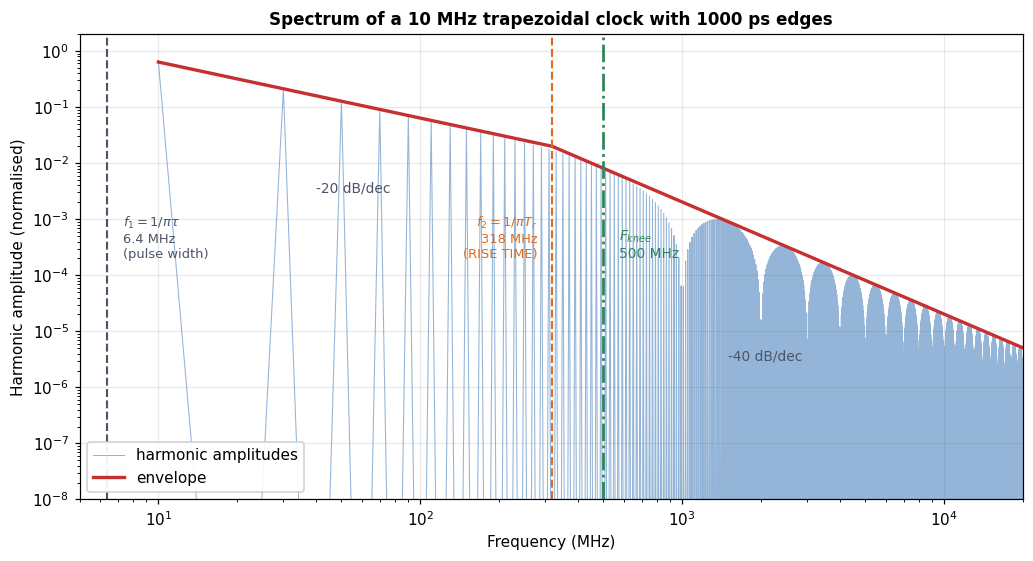

Clock frequency        :     10.0 MHz
Second envelope break  :    318.3 MHz   = 32x the clock frequency
F_knee (design proxy)  :    500.0 MHz

The clock rate tells you where the FIRST corner is. It says nothing about the second.


In [3]:
def trapezoid_spectrum(T, tau, Tr, nmax=20000):
    # harmonic amplitudes of a unit-amplitude trapezoidal pulse train
    n = np.arange(1, nmax+1)
    a = 2*(tau/T)*np.abs(sinc(n*tau/T))*np.abs(sinc(n*Tr/T))
    return n/T, a                      # frequency in 1/(time unit), amplitude

T_ns   = 100.0        # a 10 MHz clock -- deliberately slow
tau_ns = T_ns/2       # 50% duty cycle
f, a = trapezoid_spectrum(T_ns, tau_ns, Tr_ns)

f1    = 1/(np.pi*tau_ns)   # first break  [1/ns = GHz]
f2    = 1/(np.pi*Tr_ns)    # second break
Fknee = 0.5/Tr_ns

fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.loglog(f*1e3, a, lw=0.7, color=CB, alpha=0.5, label='harmonic amplitudes')

fe  = np.logspace(np.log10(f[0]), np.log10(f[-1]), 800)
env = 2*(tau_ns/T_ns)/np.maximum(1, np.pi*fe*tau_ns)/np.maximum(1, np.pi*fe*Tr_ns)
ax.loglog(fe*1e3, env, color=CR, lw=2.2, label='envelope')

ax.axvline(f1*1e3, color=CGY, ls='--', lw=1.4)
ax.text(f1*1e3*1.15, 2e-4, '$f_1 = 1/\\pi\\tau$\n%.1f MHz\n(pulse width)' % (f1*1e3),
        color=CGY, fontsize=8.5)
ax.axvline(f2*1e3, color=CO, ls='--', lw=1.4)
ax.text(f2*1e3*0.88, 2e-4, '$f_2 = 1/\\pi T_r$\n%.0f MHz\n(RISE TIME)' % (f2*1e3),
        color=CO, fontsize=8.5, ha='right')
ax.axvline(Fknee*1e3, color=CG, ls='-.', lw=1.8)
ax.text(Fknee*1e3*1.15, 2e-4, '$F_{knee}$\n%.0f MHz' % (Fknee*1e3), color=CG, fontsize=9)

ax.annotate('-20 dB/dec', xy=(40, 3e-3), color=CGY, fontsize=9)
ax.annotate('-40 dB/dec', xy=(1500, 3e-6), color=CGY, fontsize=9)

ax.set_xlim(5, 2e4); ax.set_ylim(1e-8, 2)
ax.set_xlabel('Frequency (MHz)'); ax.set_ylabel('Harmonic amplitude (normalised)')
ax.set_title('Spectrum of a %.0f MHz trapezoidal clock with %.0f ps edges'
             % (1000/T_ns, Tr_ns*1000))
ax.legend(loc='lower left')
plt.tight_layout(); plt.show()

print(f"Clock frequency        : {1000/T_ns:8.1f} MHz")
print(f"Second envelope break  : {f2*1e3:8.1f} MHz   = {f2*T_ns:.0f}x the clock frequency")
print(f"F_knee (design proxy)  : {Fknee*1e3:8.1f} MHz")
print()
print("The clock rate tells you where the FIRST corner is. It says nothing about the second.")

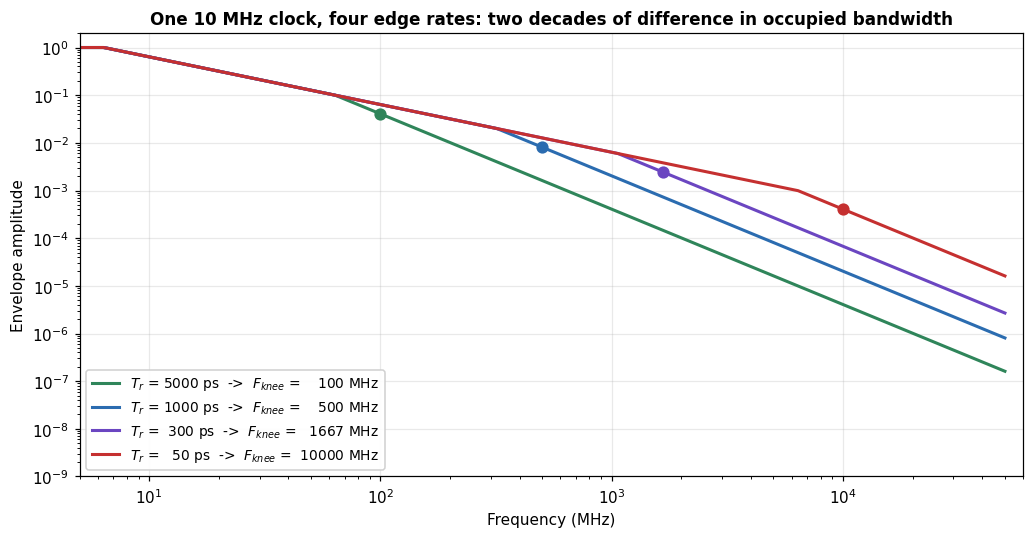

Identical clock. Identical duty cycle. The extra bandwidth is bought entirely with
edge rate -- and on most boards it is bought by accident.


In [4]:
# Hold the clock fixed at 10 MHz and vary ONLY the edge rate.
fig, ax = plt.subplots(figsize=(9.5, 5.0))
for Tr, col in zip([5.0, 1.0, 0.3, 0.05], [CG, CB, CP, CR]):
    fe  = np.logspace(-2.3, 1.7, 900)
    env = 2*0.5/np.maximum(1, np.pi*fe*tau_ns)/np.maximum(1, np.pi*fe*Tr)
    ax.loglog(fe*1e3, env, lw=2, color=col,
              label='$T_r$ = %4.0f ps  ->  $F_{knee}$ = %6.0f MHz' % (Tr*1000, 0.5/Tr*1e3))
    fk = 0.5/Tr
    ax.plot(fk*1e3, 2*0.5/(np.pi*fk*tau_ns)/max(1, np.pi*fk*Tr), 'o', color=col, ms=7)

ax.set_xlim(5, 6e4); ax.set_ylim(1e-9, 2)
ax.set_xlabel('Frequency (MHz)'); ax.set_ylabel('Envelope amplitude')
ax.set_title('One 10 MHz clock, four edge rates: two decades of difference in occupied bandwidth')
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout(); plt.show()

print("Identical clock. Identical duty cycle. The extra bandwidth is bought entirely with")
print("edge rate -- and on most boards it is bought by accident.")

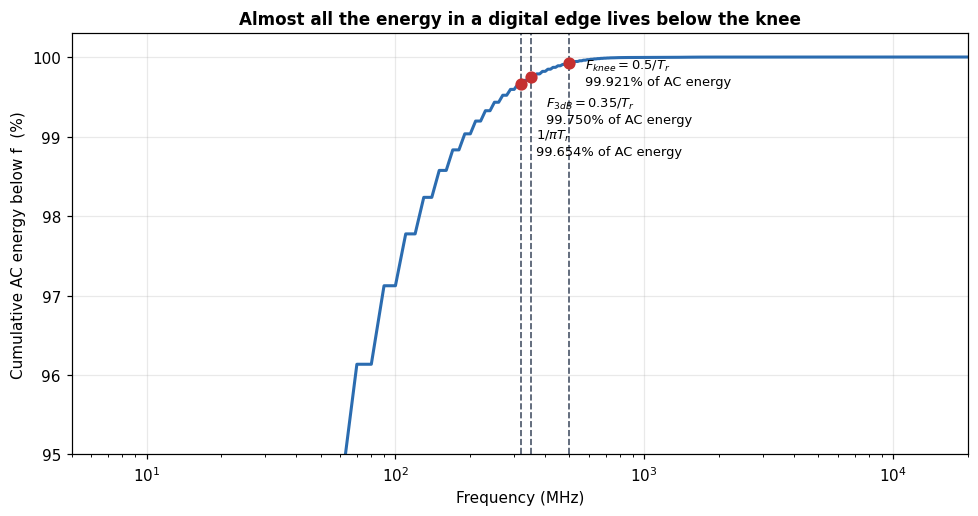

This is why F_knee works as a design proxy: what happens above it moves a fraction
of a percent of the edge's energy, and therefore cannot change the edge's shape much.


In [5]:
# What fraction of the edge's energy actually sits below F_knee?
f, a = trapezoid_spectrum(T_ns, tau_ns, Tr_ns, nmax=400000)
cum  = np.cumsum(a**2)/np.sum(a**2)

fig, ax = plt.subplots()
ax.semilogx(f*1e3, 100*cum, lw=2, color=CB)
for fx, lab, dy in [(0.35/Tr_ns, '$F_{3dB}=0.35/T_r$', -30),
                    (Fknee,      '$F_{knee}=0.5/T_r$', -14),
                    (f2,         '$1/\\pi T_r$',       -46)]:
    pct = 100*np.interp(fx, f, cum)
    ax.axvline(fx*1e3, ls='--', lw=1.1, color=CGY)
    ax.plot(fx*1e3, pct, 'o', color=CR, ms=7)
    ax.annotate('%s\n%.3f%% of AC energy' % (lab, pct), (fx*1e3, pct),
                textcoords='offset points', xytext=(10, dy), fontsize=8.5)
ax.set_xlabel('Frequency (MHz)'); ax.set_ylabel('Cumulative AC energy below f  (%)')
ax.set_ylim(95, 100.3); ax.set_xlim(5, 2e4)
ax.set_title('Almost all the energy in a digital edge lives below the knee')
plt.tight_layout(); plt.show()

print("This is why F_knee works as a design proxy: what happens above it moves a fraction")
print("of a percent of the edge's energy, and therefore cannot change the edge's shape much.")

---
## 2. The knee frequency

$$\boxed{F_{knee} = \frac{0.5}{T_r}}$$

The exact envelope break is $1/(\pi T_r) = 0.318/T_r$. Johnson rounds **up** to $0.5/T_r$ to stay
conservative. Three claims ride on it:

1. Circuit behaviour **at** $F_{knee}$ determines how the circuit processes a step edge.
2. Any circuit flat out to $F_{knee}$ passes a step with acceptable fidelity.
3. Circuit behaviour **above** $F_{knee}$ has little effect on digital performance.

### $F_{knee}$ is not $F_{3dB}$

$$F_{3dB} = \frac{K}{T_r},\qquad K = 0.338\ \text{(Gaussian)},\ \ 0.350\ \text{(single-pole RC)}$$

$F_{3dB}$ is a measured, physically defined quantity. $F_{knee}$ is a deliberately conservative
heuristic sitting about 43% above it. Keep them separate: use $F_{3dB}$ in a filter calculation, use
$F_{knee}$ to decide what matters.

Knee frequency by logic family
Logic family    Tr (ps)  F_knee     F_3dB      ratio
--------------  -------  ---------  ---------  -----
Standard TTL    5000     100        70         1.43x
LS TTL          2000     250        175        1.43x
Fast CMOS       1000     500        350        1.43x
ACT / LVCMOS    600      833        583        1.43x
LVDS            300      1.67 GHz   1.17 GHz   1.43x
DDR4 (~100 ps)  100      5.00 GHz   3.50 GHz   1.43x
SerDes PAM4     30       16.67 GHz  11.67 GHz  1.43x



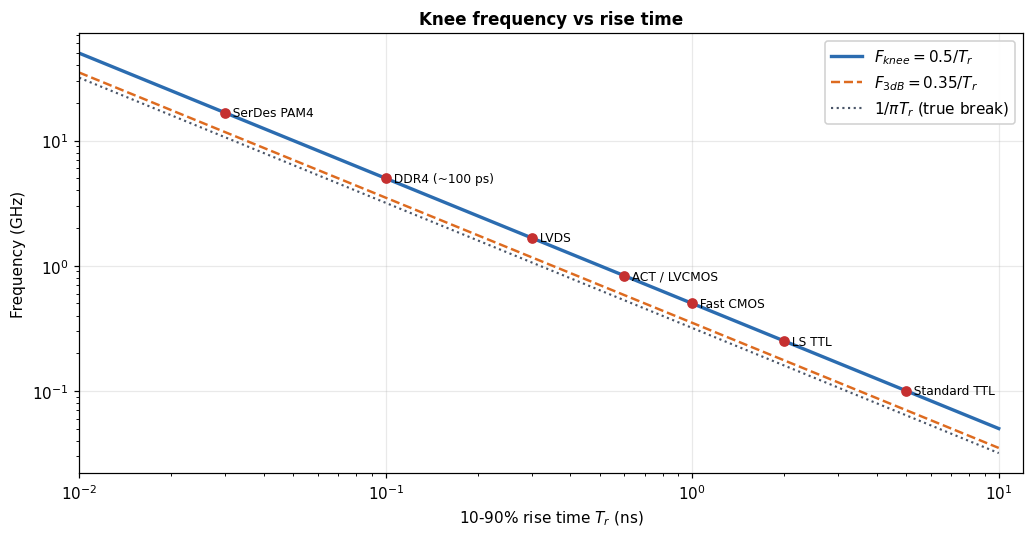

In [6]:
rows = []
for name, Tr in LOGIC_FAMILIES.items():
    fk  = 0.5/Tr        # GHz when Tr is in ns
    f3  = 0.35/Tr
    rows.append([name, f"{Tr*1000:.0f}", f"{fk*1000:.0f}" if fk < 1 else f"{fk:.2f} GHz",
                 f"{f3*1000:.0f}" if f3 < 1 else f"{f3:.2f} GHz",
                 f"{fk/f3:.2f}x"])
table(rows, ['Logic family', 'Tr (ps)', 'F_knee', 'F_3dB', 'ratio'],
      'Knee frequency by logic family')

fig, ax = plt.subplots(figsize=(9.5, 5.0))
Tr_sweep = np.logspace(np.log10(0.01), np.log10(10), 400)
ax.loglog(Tr_sweep, 0.5/Tr_sweep,  lw=2.2, color=CB, label='$F_{knee}=0.5/T_r$')
ax.loglog(Tr_sweep, 0.35/Tr_sweep, lw=1.6, color=CO, ls='--', label='$F_{3dB}=0.35/T_r$')
ax.loglog(Tr_sweep, 1/(np.pi*Tr_sweep), lw=1.4, color=CGY, ls=':', label='$1/\\pi T_r$ (true break)')

for name, Tr in LOGIC_FAMILIES.items():
    ax.plot(Tr, 0.5/Tr, 'o', color=CR, ms=6)
    ax.annotate('  ' + name, (Tr, 0.5/Tr), fontsize=8, va='center')

ax.set_xlabel('10-90% rise time $T_r$ (ns)')
ax.set_ylabel('Frequency (GHz)')
ax.set_title('Knee frequency vs rise time')
ax.legend(loc='upper right')
ax.set_xlim(0.01, 12)
plt.tight_layout(); plt.show()

### Does the claim actually hold? Filter a real edge and look.

Claim 2 says a channel flat out to $F_{knee}$ passes a step acceptably. That is testable. Below, a
trapezoidal edge is pushed through a single-pole low-pass whose corner is a chosen multiple of
$F_{knee}$, and the resulting 10-90% rise time is measured.

synthesised trapezoid: 0-100% ramp 1000 ps -> 10-90% = 800 ps


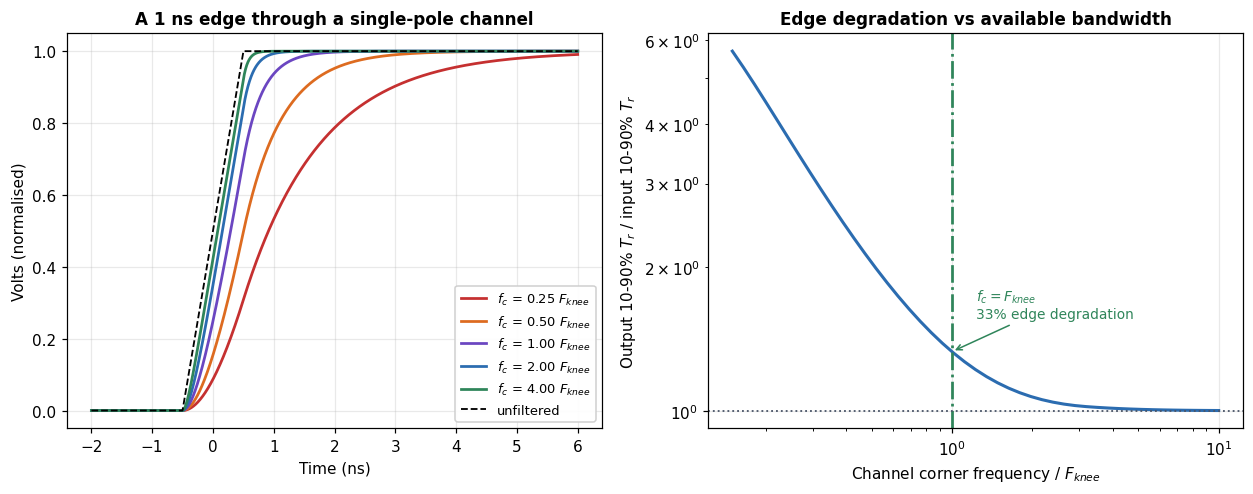

Measured edge degradation (unfiltered 10-90% Tr = 800 ps)
fc / F_knee  output 10-90% Tr (ps)  degradation
-----------  ---------------------  -----------
0.25         2920                   +265%      
0.50         1637                   +105%      
1.00         1064                   +33%       
2.00         855                    +7%        
4.00         809                    +1%        

Bandwidth equal to F_knee costs only a few percent of edge. Half of F_knee costs about a
third, and a quarter of F_knee more than doubles the edge. That is the quantitative
content of 'a circuit flat to F_knee passes a step with acceptable fidelity'.


In [7]:
def filtered_edge(Tr, fc, T=40.0, nmax=6000, npts=4000):
    # Fourier-synthesise a trapezoid, apply a single-pole low-pass, return (t, v)
    tau = T/2
    n   = np.arange(1, nmax+1)
    fn  = n/T
    an  = 2*(tau/T)*sinc(n*tau/T)*sinc(n*Tr/T)
    H   = 1.0/(1 + 1j*fn/fc)
    t   = np.linspace(-T/4, T/4, npts)
    # phase reference chosen so the RISING edge sits at t = 0
    ph  = 2*np.pi*fn[:, None]*(t[None, :] - tau/2)
    v   = (tau/T) + np.sum((an[:, None]*H[:, None]).real*np.cos(ph)
                           - (an[:, None]*H[:, None]).imag*np.sin(ph), axis=0)
    return t, v

Tr_test = 1.0
Fk      = 0.5/Tr_test

# reference: the 10-90% rise time of the UNFILTERED synthesised edge
t0, v0 = filtered_edge(Tr_test, 500*Fk)
tr0 = rise_time_10_90(*[a[(t0 > -2) & (t0 < 10)] for a in (t0, v0)])
print(f"synthesised trapezoid: 0-100% ramp {Tr_test*1000:.0f} ps -> 10-90% = {tr0*1000:.0f} ps")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))

results = []
for mult, col in zip([0.25, 0.5, 1.0, 2.0, 4.0], [CR, CO, CP, CB, CG]):
    t, v = filtered_edge(Tr_test, mult*Fk)
    m = (t > -2) & (t < 6)
    axes[0].plot(t[m], v[m], lw=1.8, color=col, label='$f_c$ = %.2f $F_{knee}$' % mult)
    trm = rise_time_10_90(*[a[(t > -2) & (t < 10)] for a in (t, v)])
    results.append((mult, trm))

t, v = filtered_edge(Tr_test, 500*Fk)
m = (t > -2) & (t < 6)
axes[0].plot(t[m], v[m], lw=1.2, color='k', ls='--', label='unfiltered')
axes[0].set_xlabel('Time (ns)'); axes[0].set_ylabel('Volts (normalised)')
axes[0].set_title('A 1 ns edge through a single-pole channel')
axes[0].legend(fontsize=8.5, loc='lower right')

mults = np.logspace(np.log10(0.15), np.log10(10), 45)
trs   = []
for mm in mults:
    t, v = filtered_edge(Tr_test, mm*Fk)
    m = (t > -2) & (t < 10)
    trs.append(rise_time_10_90(t[m], v[m]))
trs = np.array(trs)

axes[1].loglog(mults, trs/tr0, lw=2, color=CB)
axes[1].axvline(1.0, color=CG, ls='-.', lw=1.8)
axes[1].axhline(1.0, color=CGY, ls=':', lw=1.2)
axes[1].annotate('$f_c = F_{knee}$\n%.0f%% edge degradation' % (100*(np.interp(1.0, mults, trs)/tr0-1)),
                 (1.0, np.interp(1.0, mults, trs)/tr0), textcoords='offset points',
                 xytext=(16, 22), fontsize=9, color=CG,
                 arrowprops=dict(arrowstyle='->', color=CG))
axes[1].set_xlabel('Channel corner frequency / $F_{knee}$')
axes[1].set_ylabel('Output 10-90% $T_r$ / input 10-90% $T_r$')
axes[1].set_title('Edge degradation vs available bandwidth')
plt.tight_layout(); plt.show()

table([[f"{m:.2f}", f"{tr*1000:.0f}", f"{100*(tr/tr0-1):+.0f}%"] for m, tr in results],
      ['fc / F_knee', 'output 10-90% Tr (ps)', 'degradation'],
      f'Measured edge degradation (unfiltered 10-90% Tr = {tr0*1000:.0f} ps)')
print("Bandwidth equal to F_knee costs only a few percent of edge. Half of F_knee costs about a")
print("third, and a quarter of F_knee more than doubles the edge. That is the quantitative")
print("content of 'a circuit flat to F_knee passes a step with acceptable fidelity'.")

---
## 3. Turning nanoseconds into inches

Signals travel as waves at a velocity fixed by the dielectric they are embedded in:

$$v = \frac{c}{\sqrt{\varepsilon_{r,eff}}}, \qquad D = \frac{1}{v} = 85\sqrt{\varepsilon_{r,eff}}\ \text{ps/in}$$

Microstrip is *faster* than stripline on the same board because part of its field returns through air,
pulling the effective permittivity below the bulk value. That is not a rounding detail: it means
**length matching in inches is wrong across a layer change.** Match in picoseconds.

Propagation delay by medium
Medium                   er_eff  v (in/ns)  D (ps/in)
-----------------------  ------  ---------  ---------
Air / free space         1.00    11.80      85       
Coax (VF 0.75)           1.78    8.85       113      
Coax (VF 0.66)           2.30    7.79       128      
FR-4 microstrip (outer)  3.10    6.70       149      
FR-4 stripline (inner)   4.30    5.69       176      
Alumina stripline        10.00   3.73       268      



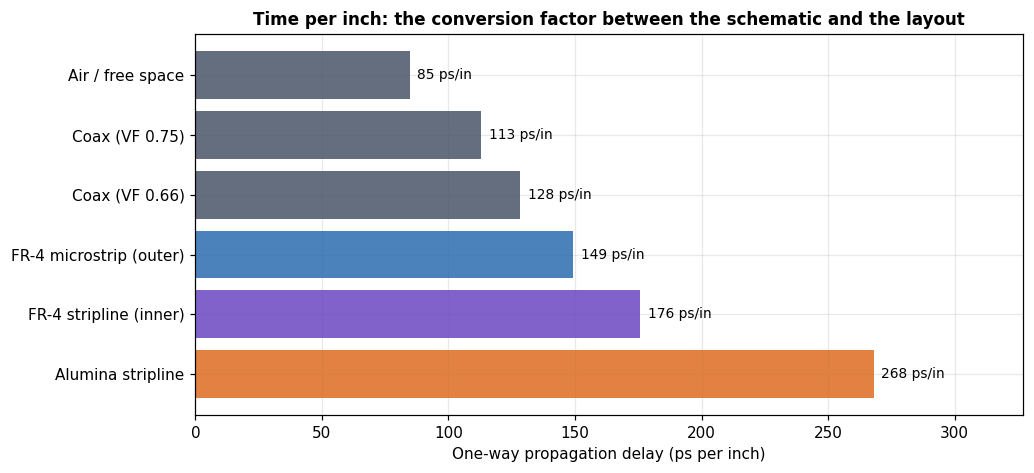

In [8]:
rows, names, delays = [], [], []
for name, (er, v) in MEDIA.items():
    D = 1000.0/v
    rows.append([name, f"{er:.2f}", f"{v:.2f}", f"{D:.0f}"])
    names.append(name); delays.append(D)
table(rows, ['Medium', 'er_eff', 'v (in/ns)', 'D (ps/in)'], 'Propagation delay by medium')

fig, ax = plt.subplots(figsize=(9.5, 4.4))
cols = [CGY, CGY, CGY, CB, CP, CO]
bars = ax.barh(names, delays, color=cols, alpha=0.85)
for b, d in zip(bars, delays):
    ax.text(d+3, b.get_y()+b.get_height()/2, f'{d:.0f} ps/in', va='center', fontsize=9)
ax.set_xlabel('One-way propagation delay (ps per inch)')
ax.set_title('Time per inch: the conversion factor between the schematic and the layout')
ax.set_xlim(0, max(delays)*1.22)
ax.invert_yaxis()
plt.tight_layout(); plt.show()

### The length of the rising edge

$$l = T_r \times v$$

This is the distance between the point where the voltage starts to leave logic-low and the point where
it arrives at logic-high, **existing simultaneously on the same conductor**. Getting this picture in
your head is what makes the next section obvious rather than memorised.

Physical length of the rising edge in FR-4
Tr (ps)  edge length, stripline (in)  edge length, microstrip (in)
-------  ---------------------------  ----------------------------
5000     28.45                        33.51                       
2000     11.38                        13.40                       
1000     5.69                         6.70                        
500      2.85                         3.35                        
300      1.71                         2.01                        
100      0.57                         0.67                        
30       0.17                         0.20                        



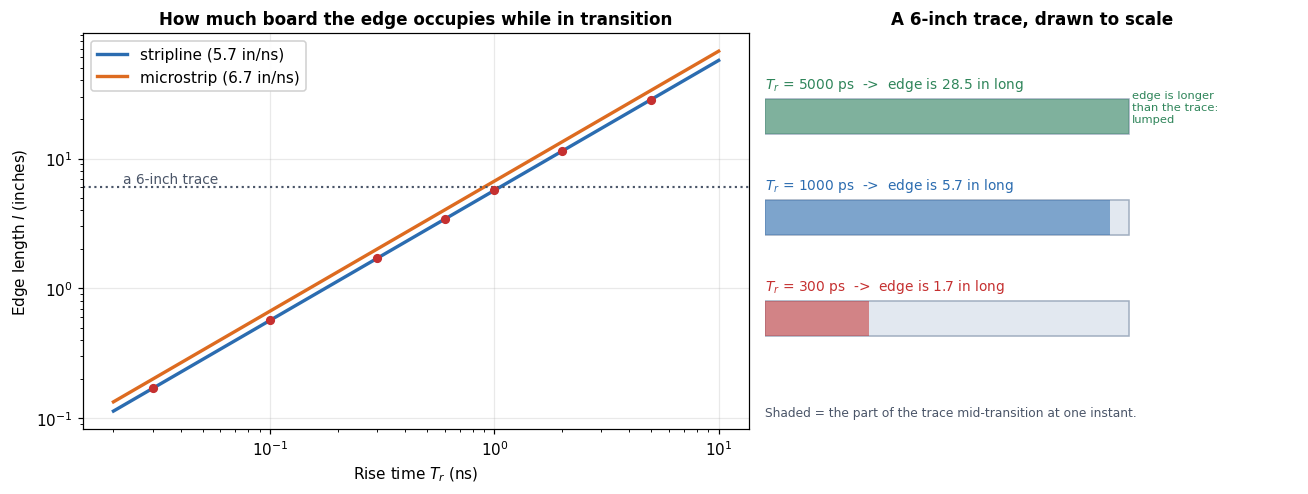

In [9]:
Tr_list = [5.0, 2.0, 1.0, 0.5, 0.3, 0.1, 0.03]
rows = [[f"{tr*1000:.0f}", f"{tr*v_stripline:.2f}", f"{tr*v_microstrip:.2f}"] for tr in Tr_list]
table(rows, ['Tr (ps)', 'edge length, stripline (in)', 'edge length, microstrip (in)'],
      'Physical length of the rising edge in FR-4')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6),
                         gridspec_kw={'width_ratios': [1.25, 1]})

# left: log-log edge length
ax = axes[0]
trs = np.logspace(np.log10(0.02), np.log10(10), 300)
ax.loglog(trs, trs*v_stripline,  lw=2.2, color=CB, label=f'stripline ({v_stripline:.1f} in/ns)')
ax.loglog(trs, trs*v_microstrip, lw=2.2, color=CO, label=f'microstrip ({v_microstrip:.1f} in/ns)')
ax.axhline(6.0, color=CGY, ls=':', lw=1.4)
ax.text(0.022, 6.5, 'a 6-inch trace', color=CGY, fontsize=9)
for name, tr in LOGIC_FAMILIES.items():
    ax.plot(tr, tr*v_stripline, 'o', color=CR, ms=5)
ax.set_xlabel('Rise time $T_r$ (ns)'); ax.set_ylabel('Edge length $l$ (inches)')
ax.set_title('How much board the edge occupies while in transition')
ax.legend(loc='upper left')

# right: to-scale picture of the edge sitting on a 6-inch trace
ax = axes[1]
ax.set_xlim(0, 8.8); ax.set_ylim(-0.5, 4.2); ax.axis('off')
ax.set_title('A 6-inch trace, drawn to scale', fontweight='bold')
for i, (tr, col) in enumerate(zip([5.0, 1.0, 0.3], [CG, CB, CR])):
    y = 3 - i*1.2
    ax.add_patch(Rectangle((0, y), 6, 0.42, facecolor='#e2e8f0', edgecolor='#a0aec0'))
    L = min(tr*v_stripline, 6)
    ax.add_patch(Rectangle((0, y), L, 0.42, facecolor=col, alpha=0.55, edgecolor='none'))
    ax.text(0, y+0.55, f'$T_r$ = {tr*1000:.0f} ps  ->  edge is {tr*v_stripline:.1f} in long',
            fontsize=9, color=col)
    if tr*v_stripline > 6:
        ax.text(6.05, y+0.15, 'edge is longer\nthan the trace:\nlumped', fontsize=7.5, color=col)
ax.text(0, -0.35, 'Shaded = the part of the trace mid-transition at one instant.', fontsize=8,
        color=CGY)
plt.tight_layout(); plt.show()

### Microstrip effective permittivity, and why it is not a constant

$\varepsilon_{r,eff}$ for microstrip depends on the trace geometry: a wide trace close to the plane
concentrates more field in the laminate and behaves more like stripline; a narrow trace lets more
field into the air. The Hammerstad closed form:

$$\varepsilon_{r,eff} = \frac{\varepsilon_r+1}{2} + \frac{\varepsilon_r-1}{2}\left(1+\frac{12h}{w}\right)^{-1/2}$$

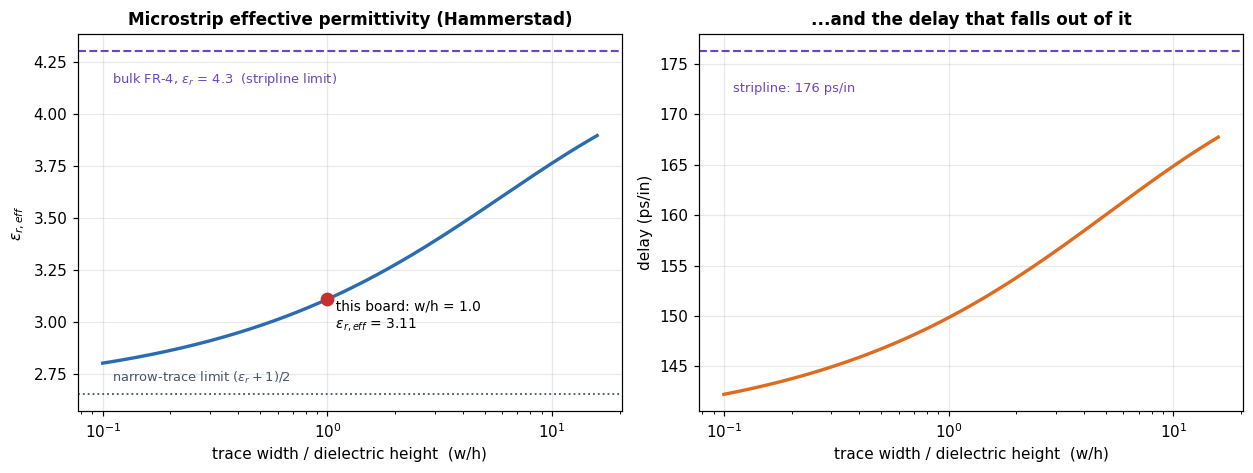

Practical consequence: a microstrip delay number quoted without the geometry is a range,
not a value -- roughly 142 to 168 ps/in for this laminate.


In [10]:
def er_eff_microstrip(er, w_over_h):
    return (er+1)/2 + (er-1)/2*(1 + 12/np.array(w_over_h))**-0.5

woh = np.logspace(-1, 1.2, 300)
ere = er_eff_microstrip(er_bulk, woh)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
ax = axes[0]
ax.semilogx(woh, ere, lw=2.2, color=CB)
ax.axhline(er_bulk, color=CP, ls='--', lw=1.4)
ax.text(0.11, er_bulk-0.15, f'bulk FR-4, $\\varepsilon_r$ = {er_bulk}  (stripline limit)',
        color=CP, fontsize=8.5)
ax.axhline((er_bulk+1)/2, color=CGY, ls=':', lw=1.2)
ax.text(0.11, (er_bulk+1)/2+0.06, 'narrow-trace limit $(\\varepsilon_r+1)/2$', color=CGY, fontsize=8.5)
whd = w_mil/h_mil
ax.plot(whd, er_eff_microstrip(er_bulk, whd), 'o', color=CR, ms=8)
ax.annotate(f'  this board: w/h = {whd:.1f}\n  $\\varepsilon_{{r,eff}}$ = {er_eff_microstrip(er_bulk, whd):.2f}',
            (whd, er_eff_microstrip(er_bulk, whd)), fontsize=9, va='top')
ax.set_xlabel('trace width / dielectric height  (w/h)')
ax.set_ylabel('$\\varepsilon_{r,eff}$')
ax.set_title('Microstrip effective permittivity (Hammerstad)')

ax = axes[1]
ax.semilogx(woh, 85*np.sqrt(ere), lw=2.2, color=CO)
ax.axhline(85*np.sqrt(er_bulk), color=CP, ls='--', lw=1.4)
ax.text(0.11, 85*np.sqrt(er_bulk)-4, 'stripline: %.0f ps/in' % (85*np.sqrt(er_bulk)),
        color=CP, fontsize=8.5)
ax.set_xlabel('trace width / dielectric height  (w/h)')
ax.set_ylabel('delay (ps/in)')
ax.set_title('...and the delay that falls out of it')
plt.tight_layout(); plt.show()

print("Practical consequence: a microstrip delay number quoted without the geometry is a range,")
print(f"not a value -- roughly {85*np.sqrt(ere.min()):.0f} to {85*np.sqrt(ere.max()):.0f} ps/in for this laminate.")

### The layer-change trap

A length-matched group routed partly on an outer layer and partly on an inner layer is **not**
time-matched. Here is the skew that buys you.

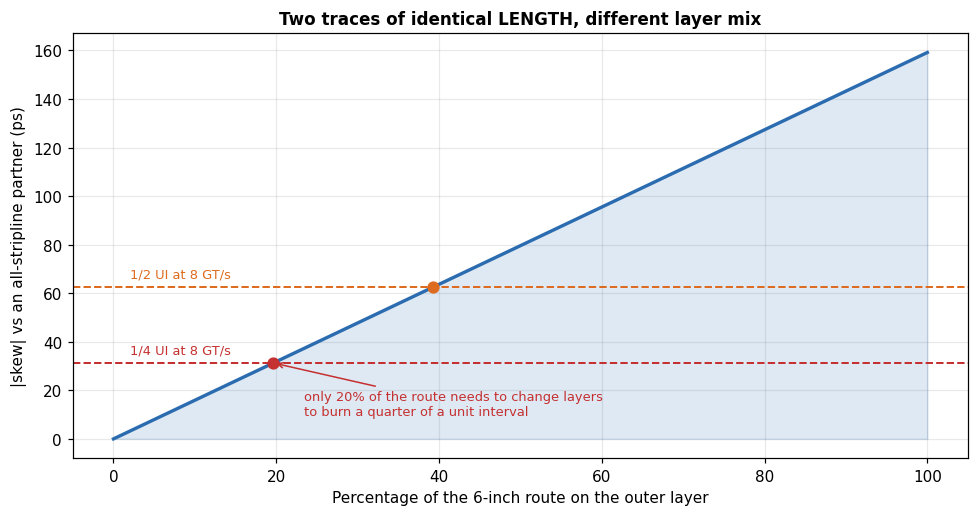

A 6-inch trace routed entirely on microstrip arrives 159 ps ahead of an identical-length stripline partner.
That is 0.91 inches of equivalent
stripline length -- the correction the layout tool must apply if it is matching in inches.


In [11]:
total_len = 6.0                      # inches, both members of the pair
frac_outer = np.linspace(0, 1, 200)  # fraction of the route on microstrip

delay_ps = frac_outer*total_len*D_microstrip + (1-frac_outer)*total_len*D_stripline
skew_ps  = np.abs(delay_ps - delay_ps[0])   # magnitude, vs an all-stripline route

fig, ax = plt.subplots()
ax.plot(100*frac_outer, skew_ps, lw=2.2, color=CB)
ax.fill_between(100*frac_outer, 0, skew_ps, color=CB, alpha=0.15)
for ui_ps, lab, col in [(31.25, '1/4 UI at 8 GT/s', CR), (62.5, '1/2 UI at 8 GT/s', CO)]:
    ax.axhline(ui_ps, color=col, ls='--', lw=1.3)
    ax.text(2, ui_ps+4, lab, color=col, fontsize=8.5)
    ax.plot(100*np.interp(ui_ps, skew_ps, frac_outer), ui_ps, 'o', color=col, ms=7)
ax.annotate('only %.0f%% of the route needs to change layers\nto burn a quarter of a unit interval'
            % (100*np.interp(31.25, skew_ps, frac_outer)),
            (100*np.interp(31.25, skew_ps, frac_outer), 31.25), textcoords='offset points',
            xytext=(20, -34), fontsize=8.5, color=CR,
            arrowprops=dict(arrowstyle='->', color=CR))
ax.set_xlabel('Percentage of the %.0f-inch route on the outer layer' % total_len)
ax.set_ylabel('|skew| vs an all-stripline partner (ps)')
ax.set_title('Two traces of identical LENGTH, different layer mix')
plt.tight_layout(); plt.show()

print(f"A {total_len:.0f}-inch trace routed entirely on microstrip arrives "
      f"{total_len*(D_stripline-D_microstrip):.0f} ps ahead of an identical-length stripline partner.")
print(f"That is {total_len*(D_stripline-D_microstrip)/D_stripline:.2f} inches of equivalent")
print("stripline length -- the correction the layout tool must apply if it is matching in inches.")

---
## 4. The decision that governs everything else

If the interconnect is much shorter than the rising edge, every point on it sits at essentially the
same potential at the same instant. Kirchhoff holds, R/L/C elements with no physical extent describe
the structure completely, and there is no characteristic impedance to match. The structure is
**lumped**.

If the interconnect is comparable to or longer than the edge, several distinct voltage levels coexist
along the conductor at once, and you need transmission line theory. The structure is **distributed**.

$$\boxed{L_{crit} = \frac{l}{6} = \frac{T_r \times v}{6}}$$

The 6 is a convention, not physics. Some designers use 4 (permissive) or 10 (conservative). Nothing
happens at the boundary; the error in the lumped approximation grows continuously. Section 4.3 below
measures what that error actually is.

**The criterion contains rise time and does not contain clock period anywhere.**

Critical length: the lumped/distributed boundary
Tr (ps)  L_crit stripline (in)  L_crit microstrip (in)  divisor 4 (in)  divisor 10 (in)
-------  ---------------------  ----------------------  --------------  ---------------
5000     4.742                  5.585                   7.113           2.845          
2000     1.897                  2.234                   2.845           1.138          
1000     0.948                  1.117                   1.423           0.569          
500      0.474                  0.558                   0.711           0.285          
300      0.285                  0.335                   0.427           0.171          
100      0.095                  0.112                   0.142           0.057          
30       0.028                  0.034                   0.043           0.017          



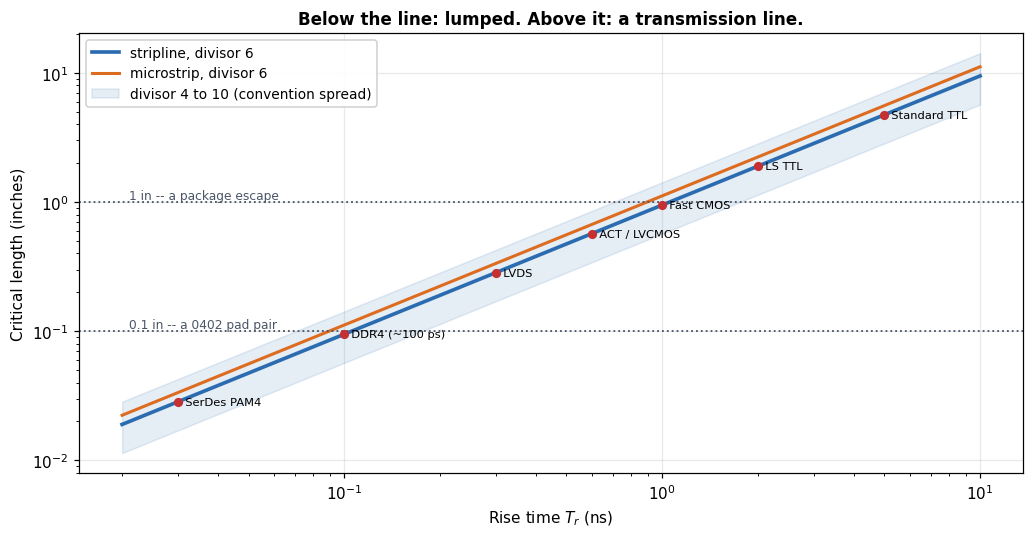

In [12]:
rows = []
for tr in Tr_list:
    rows.append([f"{tr*1000:.0f}",
                 f"{tr*v_stripline/6:.3f}", f"{tr*v_microstrip/6:.3f}",
                 f"{tr*v_stripline/4:.3f}", f"{tr*v_stripline/10:.3f}"])
table(rows, ['Tr (ps)', 'L_crit stripline (in)', 'L_crit microstrip (in)',
             'divisor 4 (in)', 'divisor 10 (in)'],
      'Critical length: the lumped/distributed boundary')

fig, ax = plt.subplots(figsize=(9.5, 5.0))
trs = np.logspace(np.log10(0.02), np.log10(10), 300)
ax.loglog(trs, trs*v_stripline/6,  lw=2.4, color=CB,  label='stripline, divisor 6')
ax.loglog(trs, trs*v_microstrip/6, lw=2.0, color=CO,  label='microstrip, divisor 6')
ax.fill_between(trs, trs*v_stripline/10, trs*v_stripline/4, color=CB, alpha=0.12,
                label='divisor 4 to 10 (convention spread)')
ax.axhline(0.1, color=CGY, ls=':', lw=1.2); ax.text(0.021, 0.105, '0.1 in -- a 0402 pad pair', fontsize=8, color=CGY)
ax.axhline(1.0, color=CGY, ls=':', lw=1.2); ax.text(0.021, 1.05, '1 in -- a package escape', fontsize=8, color=CGY)
for name, tr in LOGIC_FAMILIES.items():
    ax.plot(tr, tr*v_stripline/6, 'o', color=CR, ms=5)
    ax.annotate('  ' + name, (tr, tr*v_stripline/6), fontsize=7.5, va='center')
ax.set_xlabel('Rise time $T_r$ (ns)'); ax.set_ylabel('Critical length (inches)')
ax.set_title('Below the line: lumped. Above it: a transmission line.')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()

### 4.1 The design-space map

Trace length on one axis, rise time on the other. Everything above the boundary needs termination.

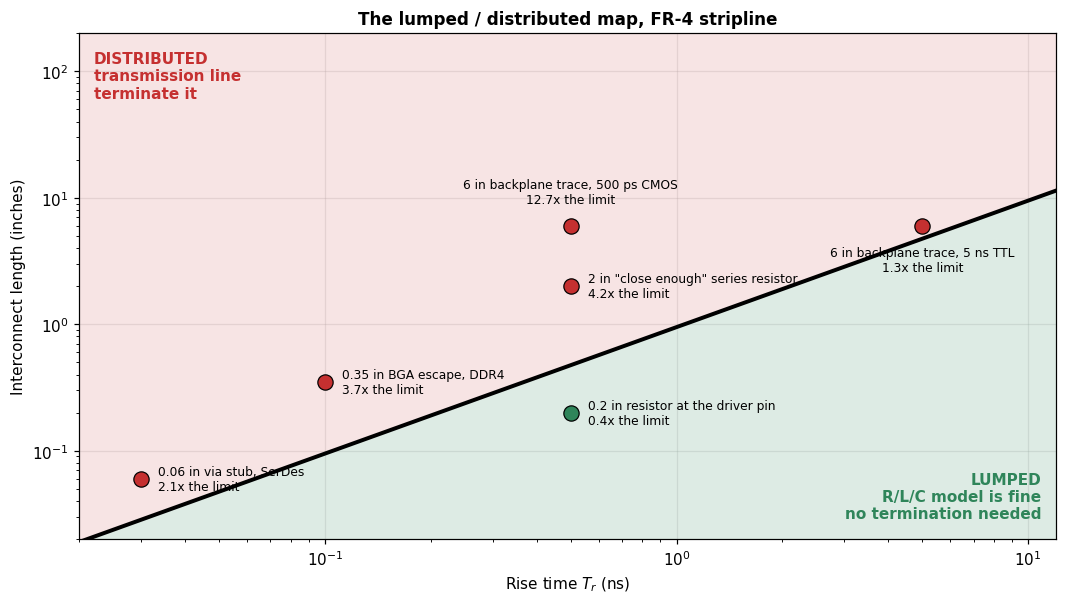

Worked cases
Structure                            Tr (ps)  length (in)  L_crit (in)  ratio  verdict    
-----------------------------------  -------  -----------  -----------  -----  -----------
6 in backplane trace, 5 ns TTL       5000     6.00         4.742        1.3x   DISTRIBUTED
6 in backplane trace, 500 ps CMOS    500      6.00         0.474        12.7x  DISTRIBUTED
2 in "close enough" series resistor  500      2.00         0.474        4.2x   DISTRIBUTED
0.2 in resistor at the driver pin    500      0.20         0.474        0.4x   LUMPED     
0.35 in BGA escape, DDR4             100      0.35         0.095        3.7x   DISTRIBUTED
0.06 in via stub, SerDes             30       0.06         0.028        2.1x   DISTRIBUTED



In [13]:
fig, ax = plt.subplots(figsize=(9.8, 5.6))
trs = np.logspace(np.log10(0.015), np.log10(15), 400)
crit = trs*v_stripline/6

ax.fill_between(trs, 1e-3, crit, color=CG, alpha=0.16)
ax.fill_between(trs, crit, 1e3, color=CR, alpha=0.13)
ax.loglog(trs, crit, lw=2.6, color='k')

ax.text(0.985, 0.035, 'LUMPED\nR/L/C model is fine\nno termination needed',
        transform=ax.transAxes, fontsize=10, color=CG, fontweight='bold',
        va='bottom', ha='right')
ax.text(0.015, 0.965, 'DISTRIBUTED\ntransmission line\nterminate it',
        transform=ax.transAxes, fontsize=10, color=CR, fontweight='bold', va='top')

PLACE = {'right':  ((11, 0),   'left',   'center'),
         'left':   ((-11, 0),  'right',  'center'),
         'above':  ((0, 13),   'center', 'bottom'),
         'below':  ((0, -13),  'center', 'top')}

EXAMPLES = [
    ('6 in backplane trace, 5 ns TTL',      5.0,  6.0,  'below'),
    ('6 in backplane trace, 500 ps CMOS',   0.5,  6.0,  'above'),
    ('2 in "close enough" series resistor', 0.5,  2.0,  'right'),
    ('0.2 in resistor at the driver pin',   0.5,  0.2,  'right'),
    ('0.35 in BGA escape, DDR4',            0.10, 0.35, 'right'),
    ('0.06 in via stub, SerDes',            0.03, 0.06, 'right'),
]
for lab, tr, L, side in EXAMPLES:
    Lc = tr*v_stripline/6
    ok = L < Lc
    off, ha, va = PLACE[side]
    ax.plot(tr, L, 'o', color=(CG if ok else CR), ms=10, mec='k', mew=0.8, zorder=5)
    ax.annotate('%s\n%.1fx the limit' % (lab, L/Lc), (tr, L), fontsize=8,
                textcoords='offset points', xytext=off, ha=ha, va=va, zorder=6)
EXAMPLES = [(a, b, c) for a, b, c, _ in EXAMPLES]

ax.set_xlim(0.02, 12); ax.set_ylim(0.02, 200)
ax.set_xlabel('Rise time $T_r$ (ns)'); ax.set_ylabel('Interconnect length (inches)')
ax.set_title('The lumped / distributed map, FR-4 stripline')
plt.tight_layout(); plt.show()

table([[lab, f"{tr*1000:.0f}", f"{L:.2f}", f"{tr*v_stripline/6:.3f}",
        f"{L/(tr*v_stripline/6):.1f}x", 'LUMPED' if L < tr*v_stripline/6 else 'DISTRIBUTED']
       for lab, tr, L in EXAMPLES],
      ['Structure', 'Tr (ps)', 'length (in)', 'L_crit (in)', 'ratio', 'verdict'],
      'Worked cases')

Note the second row. The lecture flags the commonly repeated claim that *"6 inches at 5 ns is safely
lumped"* as worth checking rather than repeating. The arithmetic below does the check.

In [14]:
L_test, Tr_test5 = 6.0, 5.0
TD  = L_test*D_stripline/1000.0        # ns
lim = Tr_test5/6.0
print(f"6-inch stripline, 5 ns edge")
print(f"  one-way delay      = {TD:.2f} ns")
print(f"  lumped budget Tr/6 = {lim:.2f} ns")
print(f"  ratio              = {TD/lim:.2f}x  ->  {'over' if TD > lim else 'under'} the limit")
print()
print("Marginally over: not a disaster, but not the comfortable lumped case it is usually")
print("described as either. Repeat the same trace at 500 ps and the picture changes completely:")
TD5 = L_test*D_stripline/1000.0
print(f"  6 in at 500 ps: {TD5/(0.5/6):.1f}x past the threshold -- at ANY clock rate, including DC.")

6-inch stripline, 5 ns edge
  one-way delay      = 1.05 ns
  lumped budget Tr/6 = 0.83 ns
  ratio              = 1.27x  ->  over the limit

Marginally over: not a disaster, but not the comfortable lumped case it is usually
described as either. Repeat the same trace at 500 ps and the picture changes completely:
  6 in at 500 ps: 12.7x past the threshold -- at ANY clock rate, including DC.


### 4.2 Where the estimates expire

Johnson is explicit that these closed forms stop working once geometry becomes genuinely
three-dimensional or frequencies push into the multi-gigahertz range, where non-TEM propagation and
complex field interaction break the analytical approximations. Knowing where your estimate expires is
part of the estimate.

### 4.3 So where does the factor of 6 come from?

The stated justification is "tolerating something in the range of 15 to 20 percent reflection error."
That is checkable. Drive a lossless line of one-way delay $T_D$ from a source impedance $R_s$ into an
open (high-impedance CMOS input) with a ramp of rise time $T_r$, sum every reflection, and measure the
overshoot at the receiver:

$$V_{load}(t) = \frac{Z_0}{Z_0+R_s}(1+\Gamma_L)\sum_{k\ge 0}(\Gamma_s\Gamma_L)^k\,\mathrm{ramp}\!\left(t-(2k{+}1)T_D\right)$$

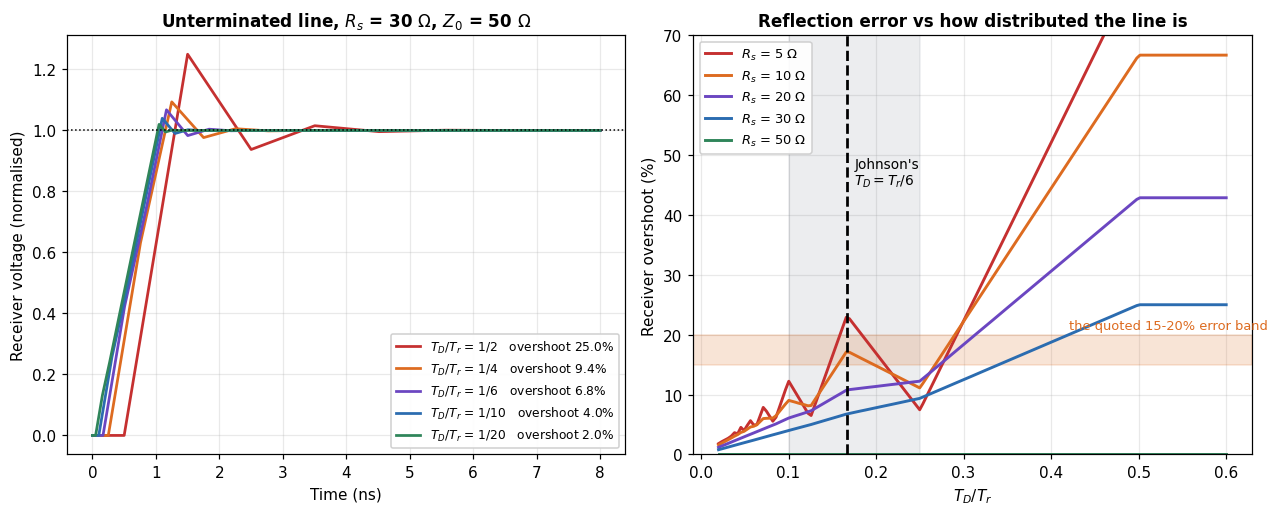

At TD/Tr = 1/6 the overshoot lands in the mid-single-digits for a well-matched 30-50 ohm
driver and climbs past 20% for a stiff low-impedance one. The ripple in the curves is real:
reflections at 2*TD reinforce or cancel against the ramp depending on the exact ratio.

So the '15-20% error' is a WORST-CASE-driver statement, not a universal one. If your driver
is series-terminated near Z0, the divisor 6 is conservative; if it is a stiff 5 ohm output,
6 is optimistic and you want 10.


In [15]:
def ramp(t, Tr):
    return np.clip(t/Tr, 0.0, 1.0)

def v_load(t, Tr, TD, Rs, Z0, GL=1.0, nrefl=300):
    Gs = (Rs-Z0)/(Rs+Z0)
    V1 = Z0/(Z0+Rs)
    v  = np.zeros_like(t)
    for k in range(nrefl):
        v += V1*(1+GL)*(Gs*GL)**k*ramp(t-(2*k+1)*TD, Tr)
    return v

Tr_ref = 1.0
t = np.linspace(0, 25*Tr_ref, 60000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ax = axes[0]
for ratio, col in zip([1/2, 1/4, 1/6, 1/10, 1/20], [CR, CO, CP, CB, CG]):
    v = v_load(t, Tr_ref, ratio*Tr_ref, Rdrv, Z0)
    m = t < 8
    ax.plot(t[m], v[m], lw=1.8, color=col,
            label='$T_D/T_r$ = 1/%.0f   overshoot %.1f%%' % (1/ratio, 100*(v.max()-1)))
ax.axhline(1.0, color='k', lw=1, ls=':')
ax.set_xlabel('Time (ns)'); ax.set_ylabel('Receiver voltage (normalised)')
ax.set_title('Unterminated line, $R_s$ = %.0f $\\Omega$, $Z_0$ = %.0f $\\Omega$' % (Rdrv, Z0))
ax.legend(fontsize=8, loc='lower right')

ax = axes[1]
ratios = np.linspace(0.02, 0.6, 160)
tt = np.linspace(0, 60*Tr_ref, 120000)
for Rs, col in zip([5, 10, 20, 30, 50], [CR, CO, CP, CB, CG]):
    ov = [100*(v_load(tt, Tr_ref, r*Tr_ref, Rs, Z0).max()-1) for r in ratios]
    ax.plot(ratios, ov, lw=1.9, color=col, label='$R_s$ = %d $\\Omega$' % Rs)
ax.axvspan(1/10, 1/4, color=CGY, alpha=0.10)
ax.axvline(1/6, color='k', ls='--', lw=1.8)
ax.text(1/6*1.05, 45, "Johnson's\n$T_D = T_r/6$", fontsize=9)
ax.axhspan(15, 20, color=CO, alpha=0.18)
ax.text(0.42, 21, 'the quoted 15-20% error band', fontsize=8.5, color=CO)
ax.set_xlabel('$T_D / T_r$'); ax.set_ylabel('Receiver overshoot (%)')
ax.set_title('Reflection error vs how distributed the line is')
ax.legend(fontsize=8.5, loc='upper left'); ax.set_ylim(0, 70)
plt.tight_layout(); plt.show()

print("At TD/Tr = 1/6 the overshoot lands in the mid-single-digits for a well-matched 30-50 ohm")
print("driver and climbs past 20% for a stiff low-impedance one. The ripple in the curves is real:")
print("reflections at 2*TD reinforce or cancel against the ramp depending on the exact ratio.")
print()
print("So the '15-20% error' is a WORST-CASE-driver statement, not a universal one. If your driver")
print("is series-terminated near Z0, the divisor 6 is conservative; if it is a stiff 5 ohm output,")
print("6 is optimistic and you want 10.")

---
## 5. Four parasitics, four equations

The chapter organises every parasitic into a 2x2: self versus mutual, electric versus magnetic.

| | Electric field | Magnetic field |
|---|---|---|
| **Self** | Ordinary capacitance $I = C\,dV/dt$ | Ordinary inductance $V = L\,dI/dt$ |
| **Mutual** | Mutual capacitance $I = C_M\,dV_A/dt$ | Mutual inductance $V_B = L_M\,dI_A/dt$ |

Two of them distort your own signal. Two of them couple you to someone else's.

### The reactance test

Evaluate every parasitic at $F_{knee}$ and compare against the surrounding impedance:

$$X_C = \frac{1}{2\pi F_{knee} C} = \frac{T_r}{\pi C}, \qquad
X_L = 2\pi F_{knee} L = \frac{\pi L}{T_r}$$

If it is negligible there, delete it from your mental model with confidence. If it is comparable, it
is a first-order effect and belongs in the simulation.

At Tr = 1 ns:
  10 pF  ->  X_C =  31.8 ohm
  10 nH  ->  X_L =  31.4 ohm
  Against a ~50 ohm environment both are first-order. Memorise this pair.



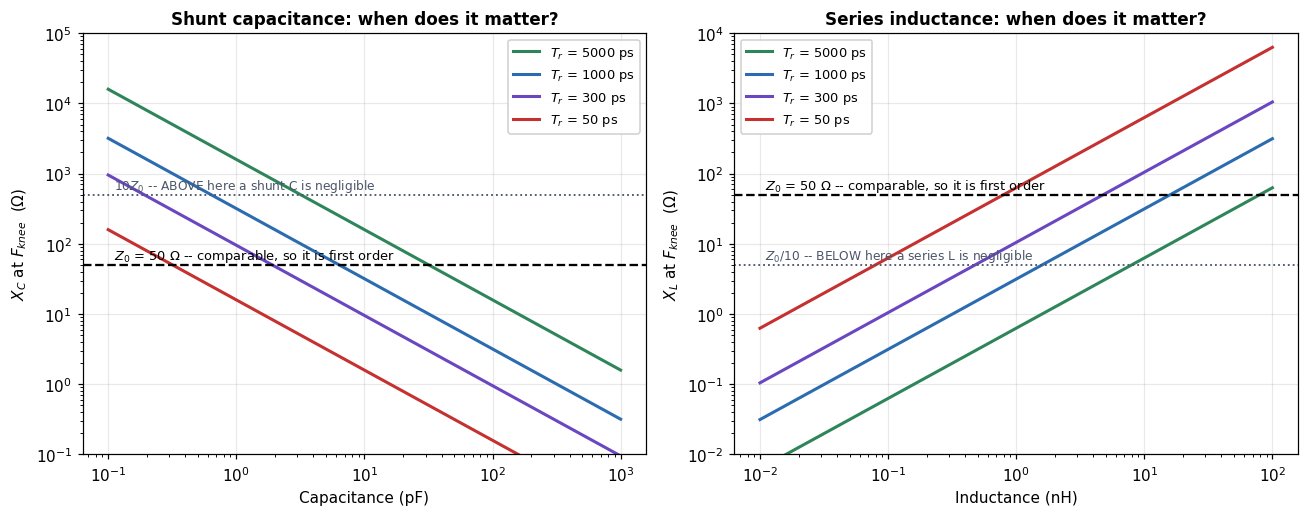

In [16]:
def X_C(C_F, Tr_s):   return Tr_s/(np.pi*C_F)
def X_L(L_H, Tr_s):   return np.pi*L_H/Tr_s

# the symmetry worth memorising
print(f"At Tr = 1 ns:")
print(f"  10 pF  ->  X_C = {X_C(10e-12, 1e-9):5.1f} ohm")
print(f"  10 nH  ->  X_L = {X_L(10e-9, 1e-9):5.1f} ohm")
print("  Against a ~50 ohm environment both are first-order. Memorise this pair.\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
Cs = np.logspace(-13, -9, 300)   # 0.1 pF to 1 nF
Ls = np.logspace(-11, -7, 300)   # 10 pH to 100 nH

ax = axes[0]
for tr, col in zip([5.0, 1.0, 0.3, 0.05], [CG, CB, CP, CR]):
    ax.loglog(Cs*1e12, X_C(Cs, tr*1e-9), lw=2, color=col, label='$T_r$ = %.0f ps' % (tr*1000))
ax.axhline(Z0, color='k', ls='--', lw=1.5)
ax.text(0.11, Z0*1.2, '$Z_0$ = %.0f $\\Omega$ -- comparable, so it is first order' % Z0, fontsize=8.5)
ax.axhline(Z0*10, color=CGY, ls=':', lw=1.2)
ax.text(0.11, Z0*10*1.2, '$10Z_0$ -- ABOVE here a shunt C is negligible', fontsize=8, color=CGY)
ax.set_xlabel('Capacitance (pF)'); ax.set_ylabel('$X_C$ at $F_{knee}$  ($\\Omega$)')
ax.set_title('Shunt capacitance: when does it matter?')
ax.legend(fontsize=8.5); ax.set_ylim(0.1, 1e5)

ax = axes[1]
for tr, col in zip([5.0, 1.0, 0.3, 0.05], [CG, CB, CP, CR]):
    ax.loglog(Ls*1e9, X_L(Ls, tr*1e-9), lw=2, color=col, label='$T_r$ = %.0f ps' % (tr*1000))
ax.axhline(Z0, color='k', ls='--', lw=1.5)
ax.text(0.011, Z0*1.2, '$Z_0$ = %.0f $\\Omega$ -- comparable, so it is first order' % Z0, fontsize=8.5)
ax.axhline(Z0/10, color=CGY, ls=':', lw=1.2)
ax.text(0.011, Z0/10*1.2, '$Z_0/10$ -- BELOW here a series L is negligible', fontsize=8, color=CGY)
ax.set_xlabel('Inductance (nH)'); ax.set_ylabel('$X_L$ at $F_{knee}$  ($\\Omega$)')
ax.set_title('Series inductance: when does it matter?')
ax.legend(fontsize=8.5); ax.set_ylim(0.01, 1e4)
plt.tight_layout(); plt.show()

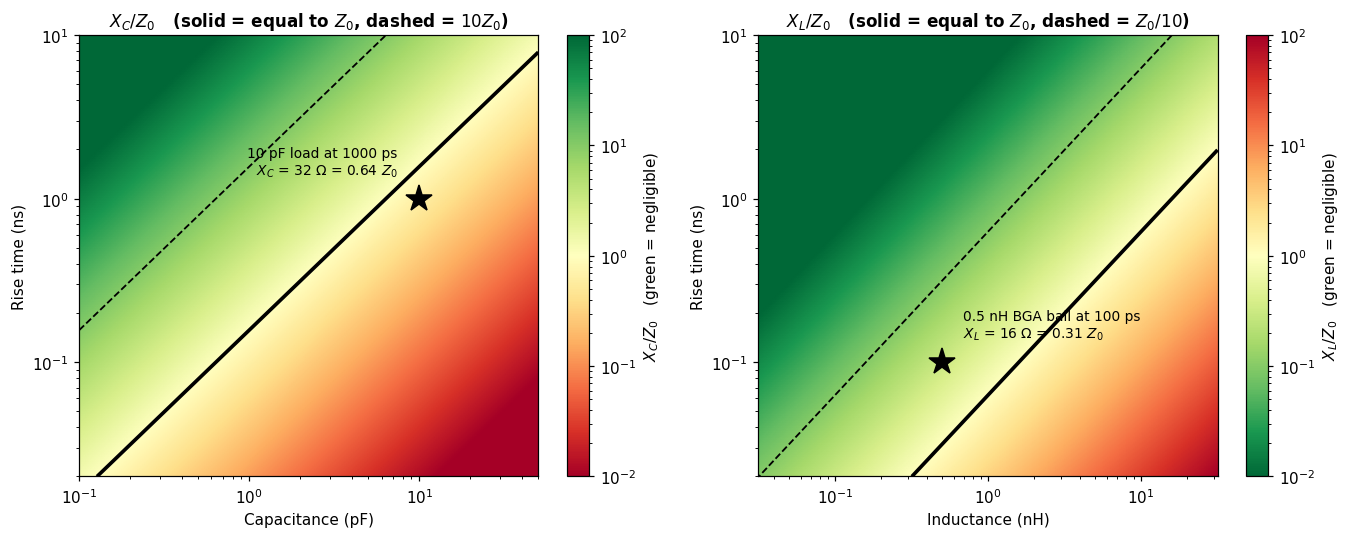

Read these as: anywhere the solid contour passes, that parasitic is a first-order circuit
element. Green is 'delete it from your mental model'; red is 'put it in the simulation'.
Both boundaries are straight lines of slope 1 on log-log axes, because both reactances
are linear in Tr. Halve the edge and every parasitic slides one step toward red.


In [17]:
# A significance map: X_C / Z0 over the (capacitance, rise time) plane.
Cg = np.logspace(-13, -10.3, 260)     # 0.1 pF .. 50 pF
Tg = np.logspace(np.log10(0.02), np.log10(10), 260)
CC, TT = np.meshgrid(Cg, Tg)
ratio_C = X_C(CC, TT*1e-9)/Z0

Lg = np.logspace(-10.5, -7.5, 260)    # 0.3 nH .. 30 nH
LL, TT2 = np.meshgrid(Lg, Tg)
ratio_L = X_L(LL, TT2*1e-9)/Z0

from matplotlib.colors import LogNorm
norm  = LogNorm(vmin=1e-2, vmax=1e2)
ticks = [1e-2, 1e-1, 1, 1e1, 1e2]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0))

ax = axes[0]
m = ax.pcolormesh(Cg*1e12, Tg, np.clip(ratio_C, 1e-2, 1e2), norm=norm, cmap='RdYlGn',
                  shading='gouraud')
ax.contour(Cg*1e12, Tg, ratio_C, levels=[1], colors='k', linewidths=2.4)
ax.contour(Cg*1e12, Tg, ratio_C, levels=[10], colors='k', linewidths=1.2, linestyles='--')
ax.set_xscale('log'); ax.set_yscale('log')
ax.plot(C_load_pF, Tr_ns, '*', color='k', ms=18, zorder=5)
ax.annotate('%.0f pF load at %.0f ps\n$X_C$ = %.0f $\\Omega$ = %.2f $Z_0$'
            % (C_load_pF, Tr_ns*1000, X_C(C_load_pF*1e-12, Tr_ns*1e-9),
               X_C(C_load_pF*1e-12, Tr_ns*1e-9)/Z0),
            (C_load_pF, Tr_ns), textcoords='offset points', xytext=(-14, 16),
            ha='right', fontsize=9)
ax.set_xlabel('Capacitance (pF)'); ax.set_ylabel('Rise time (ns)')
ax.set_title('$X_C / Z_0$   (solid = equal to $Z_0$, dashed = $10Z_0$)')
cb = plt.colorbar(m, ax=ax, ticks=ticks)
cb.set_label('$X_C/Z_0$   (green = negligible)')

ax = axes[1]
m = ax.pcolormesh(Lg*1e9, Tg, np.clip(ratio_L, 1e-2, 1e2), norm=norm, cmap='RdYlGn_r',
                  shading='gouraud')
ax.contour(Lg*1e9, Tg, ratio_L, levels=[1], colors='k', linewidths=2.4)
ax.contour(Lg*1e9, Tg, ratio_L, levels=[0.1], colors='k', linewidths=1.2, linestyles='--')
ax.set_xscale('log'); ax.set_yscale('log')
ax.plot(L_ball_nH, 0.1, '*', color='k', ms=18, zorder=5)
ax.annotate('%.1f nH BGA ball at 100 ps\n$X_L$ = %.0f $\\Omega$ = %.2f $Z_0$'
            % (L_ball_nH, X_L(L_ball_nH*1e-9, 0.1e-9), X_L(L_ball_nH*1e-9, 0.1e-9)/Z0),
            (L_ball_nH, 0.1), textcoords='offset points', xytext=(14, 16), fontsize=9)
ax.set_xlabel('Inductance (nH)'); ax.set_ylabel('Rise time (ns)')
ax.set_title('$X_L / Z_0$   (solid = equal to $Z_0$, dashed = $Z_0/10$)')
cb = plt.colorbar(m, ax=ax, ticks=ticks)
cb.set_label('$X_L/Z_0$   (green = negligible)')
plt.tight_layout(); plt.show()

print("Read these as: anywhere the solid contour passes, that parasitic is a first-order circuit")
print("element. Green is 'delete it from your mental model'; red is 'put it in the simulation'.")
print("Both boundaries are straight lines of slope 1 on log-log axes, because both reactances")
print("are linear in Tr. Halve the edge and every parasitic slides one step toward red.")

---
## 6. Self capacitance

$$I = C\,\frac{dV}{dt} \approx \frac{C\,\Delta V}{T_r}$$

Faster slew into a fixed capacitance demands proportionally more instantaneous current. A driver of
finite output impedance feeding that capacitance forms an RC, and the 10-90% rise time through it is

$$T_{r,RC} = 2.2\,RC$$

**Worked example from the lecture:** a 30 $\Omega$ driver into a 10 pF load.

In [18]:
Rs, Cl = Rdrv, C_load_pF*1e-12
Tr_rc  = 2.2*Rs*Cl
Tr_out = np.sqrt(Tr_ns**2 + (Tr_rc*1e9)**2)

print(f"Driver impedance          {Rs:.0f} ohm")
print(f"Load capacitance          {C_load_pF:.0f} pF")
print(f"RC 10-90% rise time       2.2 x {Rs:.0f} x {C_load_pF:.0f}p = {Tr_rc*1e12:.0f} ps")
print(f"Intrinsic driver edge     {Tr_ns*1000:.0f} ps")
print(f"Composite edge (RSS)      sqrt({Tr_ns:.2f}^2 + {Tr_rc*1e9:.2f}^2) = {Tr_out*1000:.0f} ps")
print()
print(f"Knee frequency before     {0.5/Tr_ns*1000:.0f} MHz")
print(f"Knee frequency after      {0.5/Tr_out*1000:.0f} MHz")
print()
print("Now the same conclusion from the frequency side:")
print(f"  X_C at F_knee = Tr/(pi*C) = {X_C(Cl, Tr_ns*1e-9):.1f} ohm, against a {Rs:.0f} ohm driver.")
print("  Same order of magnitude -> first-order effect, keep it in the model.")
print(f"  Had it come back at {X_C(0.1e-12, Tr_ns*1e-9):.0f} ohm (a 0.1 pF stub), you could delete it.")
print()
print(f"Instantaneous current demand: I = C dV/dt = {Cl*Vswing/(Tr_ns*1e-9)*1000:.0f} mA")
print("  and it has to arrive within a nanosecond, which is far too fast for the regulator.")
print("  That current is the decoupling network's job -- see section 7.")

Driver impedance          30 ohm
Load capacitance          10 pF
RC 10-90% rise time       2.2 x 30 x 10p = 660 ps
Intrinsic driver edge     1000 ps
Composite edge (RSS)      sqrt(1.00^2 + 0.66^2) = 1198 ps

Knee frequency before     500 MHz
Knee frequency after      417 MHz

Now the same conclusion from the frequency side:
  X_C at F_knee = Tr/(pi*C) = 31.8 ohm, against a 30 ohm driver.
  Same order of magnitude -> first-order effect, keep it in the model.
  Had it come back at 3183 ohm (a 0.1 pF stub), you could delete it.

Instantaneous current demand: I = C dV/dt = 33 mA
  and it has to arrive within a nanosecond, which is far too fast for the regulator.
  That current is the decoupling network's job -- see section 7.


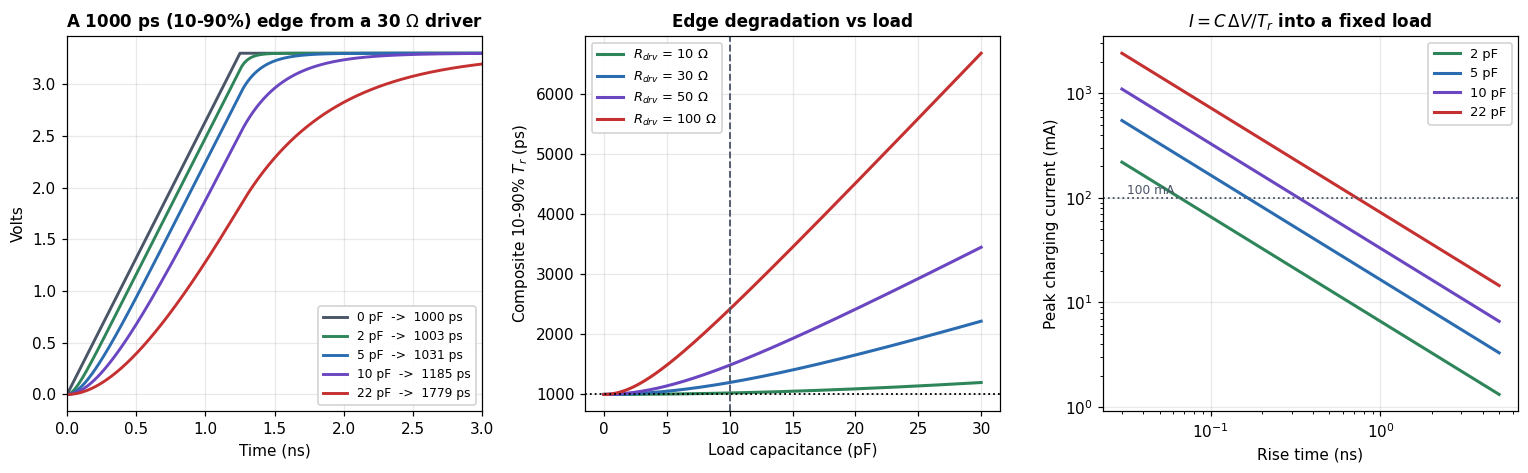

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))

# --- (a) time domain: the edge slowed by RC ---
ax = axes[0]
t = np.linspace(0, 5, 4000)      # ns
Tramp = Tr_ns/0.8                # full 0-100% ramp whose 10-90% time equals Tr_ns
for C_pF, col in zip([0, 2, 5, 10, 22], [CGY, CG, CB, CP, CR]):
    tau = Rs*C_pF*1e-12*1e9      # ns
    if tau == 0:
        vv = np.clip(t/Tramp, 0, 1)
    else:
        # ramp convolved with a single-pole RC
        vv = np.where(t < Tramp,
                      (t - tau*(1-np.exp(-t/tau)))/Tramp,
                      (Tramp - tau*(np.exp(-(t-Tramp)/tau) - np.exp(-t/tau)))/Tramp)
        vv = np.clip(vv, 0, None)
    trm = rise_time_10_90(t, vv)
    ax.plot(t, Vswing*vv, lw=1.9, color=col, label='%g pF  ->  %.0f ps' % (C_pF, trm*1000))
ax.set_xlabel('Time (ns)'); ax.set_ylabel('Volts')
ax.set_title('A %.0f ps (10-90%%) edge from a %.0f $\\Omega$ driver' % (Tr_ns*1000, Rs))
ax.legend(fontsize=8, loc='lower right'); ax.set_xlim(0, 3)

# --- (b) composite rise time vs load capacitance ---
ax = axes[1]
Cs = np.linspace(0, 30, 200)
for R, col in zip([10, 30, 50, 100], [CG, CB, CP, CR]):
    trc = 2.2*R*Cs*1e-12*1e9
    ax.plot(Cs, np.sqrt(Tr_ns**2 + trc**2)*1000, lw=2, color=col, label='$R_{drv}$ = %d $\\Omega$' % R)
ax.axhline(Tr_ns*1000, color='k', ls=':', lw=1.2)
ax.axvline(C_load_pF, color=CGY, ls='--', lw=1.2)
ax.set_xlabel('Load capacitance (pF)'); ax.set_ylabel('Composite 10-90% $T_r$ (ps)')
ax.set_title('Edge degradation vs load')
ax.legend(fontsize=8.5)

# --- (c) current demand ---
ax = axes[2]
trs = np.logspace(np.log10(0.03), np.log10(5), 200)
for C_pF, col in zip([2, 5, 10, 22], [CG, CB, CP, CR]):
    ax.loglog(trs, C_pF*1e-12*Vswing/(trs*1e-9)*1000, lw=2, color=col, label='%g pF' % C_pF)
ax.axhline(100, color=CGY, ls=':', lw=1.2); ax.text(0.032, 110, '100 mA', fontsize=8, color=CGY)
ax.set_xlabel('Rise time (ns)'); ax.set_ylabel('Peak charging current (mA)')
ax.set_title('$I = C\\,\\Delta V/T_r$ into a fixed load')
ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

---
## 7. Self inductance: ground bounce and decoupling

$$V = L\,\frac{dI}{dt}$$

A switching output pulls a current surge; that surge crossing the parasitic inductance of the power
and ground path produces a voltage across it. The die's local ground reference shifts relative to
system ground. That is **ground bounce**, and once several outputs do it together, **simultaneous
switching noise (SSN)**.

**Worked example, TTL era:** one output driving a 50 $\Omega$ line to 3.3 V, delivered in 1 ns,
through a 5 nH package ground lead.

In [20]:
def ground_bounce(n_out, I_out_A, Tr_s, L_H, n_pins=1):
    "Bounce voltage for n simultaneously switching outputs sharing n_pins return leads."
    return n_out*I_out_A/Tr_s*(L_H/n_pins)

I1  = Vswing/Z0
dIdt = I1/(Tr_ns*1e-9)
print(f"One output into {Z0:.0f} ohm at {Vswing} V   ->  I = {I1*1000:.0f} mA")
print(f"Delivered in {Tr_ns*1000:.0f} ps                    ->  dI/dt = {dIdt:.2e} A/s")
print(f"Across a {L_gnd_nH:.0f} nH ground lead        ->  V = {ground_bounce(1, I1, Tr_ns*1e-9, L_gnd_nH*1e-9):.2f} V")
print(f"Eight outputs on the same lead      ->  V = {ground_bounce(8, I1, Tr_ns*1e-9, L_gnd_nH*1e-9):.2f} V")
print("\nThat is not a margin problem, it is a functional failure. This is exactly why wide buses")
print("on cheap packages with one ground pin were a catastrophe in the TTL era.\n")

print("The modern version:")
I2 = 0.020
for n_balls in [1, 4, 10, 20]:
    vb = ground_bounce(20, I2, 0.5e-9, L_ball_nH*1e-9, n_balls)
    print(f"  20 outputs @ 20 mA, 500 ps edges, through {n_balls:2d} x {L_ball_nH} nH ball(s): {vb*1000:6.0f} mV")
print("\nGround ball count is a signal integrity parameter, not a mechanical one.")

One output into 50 ohm at 3.3 V   ->  I = 66 mA
Delivered in 1000 ps                    ->  dI/dt = 6.60e+07 A/s
Across a 5 nH ground lead        ->  V = 0.33 V
Eight outputs on the same lead      ->  V = 2.64 V

That is not a margin problem, it is a functional failure. This is exactly why wide buses
on cheap packages with one ground pin were a catastrophe in the TTL era.

The modern version:
  20 outputs @ 20 mA, 500 ps edges, through  1 x 0.5 nH ball(s):    400 mV
  20 outputs @ 20 mA, 500 ps edges, through  4 x 0.5 nH ball(s):    100 mV
  20 outputs @ 20 mA, 500 ps edges, through 10 x 0.5 nH ball(s):     40 mV
  20 outputs @ 20 mA, 500 ps edges, through 20 x 0.5 nH ball(s):     20 mV

Ground ball count is a signal integrity parameter, not a mechanical one.


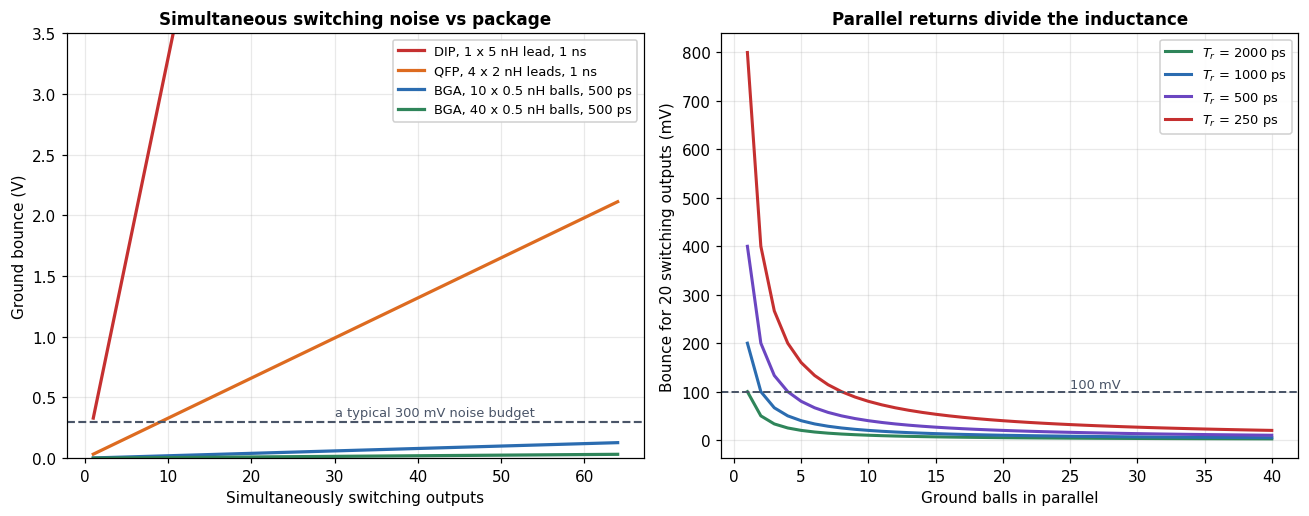

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

ax = axes[0]
n = np.arange(1, 65)
PKGS = [('DIP, 1 x 5 nH lead, 1 ns',      5.0,  1, 1.0, I1,   CR),
        ('QFP, 4 x 2 nH leads, 1 ns',     2.0,  4, 1.0, I1,   CO),
        ('BGA, 10 x 0.5 nH balls, 500 ps',0.5, 10, 0.5, 0.02, CB),
        ('BGA, 40 x 0.5 nH balls, 500 ps',0.5, 40, 0.5, 0.02, CG)]
for lab, Lp, npins, tr, Iout, col in PKGS:
    ax.plot(n, ground_bounce(n, Iout, tr*1e-9, Lp*1e-9, npins), lw=2.1, color=col, label=lab)
ax.axhline(0.3, color=CGY, ls='--', lw=1.4)
ax.text(30, 0.35, 'a typical 300 mV noise budget', fontsize=8.5, color=CGY)
ax.set_xlabel('Simultaneously switching outputs'); ax.set_ylabel('Ground bounce (V)')
ax.set_title('Simultaneous switching noise vs package')
ax.set_ylim(0, 3.5); ax.legend(fontsize=8.5)

ax = axes[1]
nb = np.arange(1, 41)
for tr, col in zip([2.0, 1.0, 0.5, 0.25], [CG, CB, CP, CR]):
    ax.plot(nb, 1000*ground_bounce(20, 0.02, tr*1e-9, L_ball_nH*1e-9, nb), lw=2,
            color=col, label='$T_r$ = %.0f ps' % (tr*1000))
ax.axhline(100, color=CGY, ls='--', lw=1.3); ax.text(25, 108, '100 mV', fontsize=8.5, color=CGY)
ax.set_xlabel('Ground balls in parallel'); ax.set_ylabel('Bounce for 20 switching outputs (mV)')
ax.set_title('Parallel returns divide the inductance')
ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

### Inductance is a property of a loop, not a wire

Total loop inductance scales with the **physical area enclosed** by the outgoing signal path and its
return. Bring the return closer and the area shrinks. Because the return current flows opposite to the
signal current, mutual inductance between the two partially cancels the self inductance of each.

That single fact is the theoretical seed of every ground-plane rule in the rest of the book:
continuous reference planes, no splits under high-speed traces, and a stitching via next to every
layer-changing signal via so the return current has a low-area path to follow.

For a trace of width $w$ at height $h$ over a plane, the loop inductance per unit length is
approximately $L' \approx \mu_0 h/w$ (wide-trace limit) — i.e. **proportional to the loop area per
inch**. A "ground pin inductance" figure quoted without its return path is meaningless.

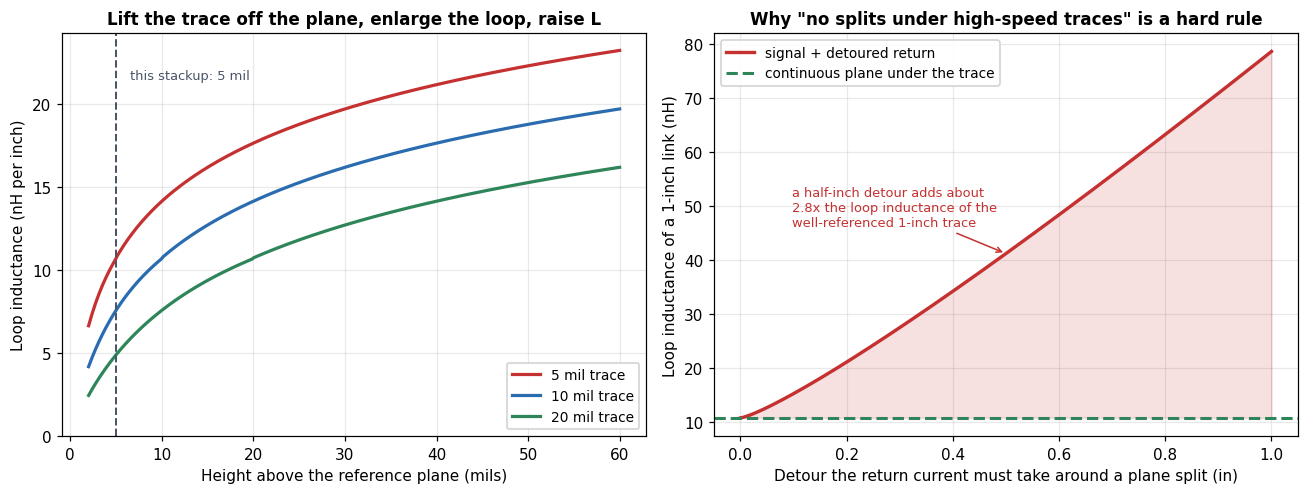

L' for this stackup (5 mil trace, 5 mil above the plane): 10.7 nH/in, Z0 = 72 ohm.

The right-hand plot uses a wire-inductance estimate for the detour, not a field solve.
The scaling is the point: a detour measured in tenths of an inch adds inductance
comparable to inches of ordinary, well-referenced routing.


In [22]:
def z0_microstrip(w_over_h, er=er_bulk):
    "Hammerstad closed form for microstrip characteristic impedance."
    woh = np.asarray(w_over_h, dtype=float)
    ere = er_eff_microstrip(er, woh)
    narrow = (60/np.sqrt(ere))*np.log(8/woh + woh/4)
    wide   = 120*np.pi/(np.sqrt(ere)*(woh + 1.393 + 0.667*np.log(woh + 1.444)))
    return np.where(woh <= 1, narrow, wide), ere

def L_per_inch_nH(w_over_h, er=er_bulk):
    "Loop inductance per inch: L' = Z0/v = Z0*sqrt(er_eff)/c."
    z0, ere = z0_microstrip(w_over_h, er)
    return z0*np.sqrt(ere)/c_m_s*IN*1e9

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

# --- loop inductance vs height over the plane, for a few trace widths ---
ax = axes[0]
h = np.linspace(2, 60, 300)                          # mils
for wm, col in zip([5, 10, 20], [CR, CB, CG]):
    ax.plot(h, L_per_inch_nH(wm/h), lw=2.1, color=col, label='%d mil trace' % wm)
ax.axvline(h_mil, color=CGY, ls='--', lw=1.3)
ax.text(h_mil+1.5, 21.5, 'this stackup: %d mil' % h_mil, fontsize=8.5, color=CGY)
ax.set_xlabel('Height above the reference plane (mils)')
ax.set_ylabel('Loop inductance (nH per inch)')
ax.set_title('Lift the trace off the plane, enlarge the loop, raise L')
ax.legend(fontsize=9); ax.set_ylim(0, None)

# --- what a plane split costs: the return current forced around a gap ---
ax = axes[1]
L_base = L_per_inch_nH(w_mil/h_mil)                  # nH per inch, tight to the plane
trace_len = 1.0                                      # inches of signal we are accounting for
detour = np.linspace(0, 1.0, 200)                    # inches the return must go around
L_extra = 2*detour*(mu0/np.pi)*IN*1e9*np.log(4*(detour*IN + 1e-4)/(w_mil*MIL))/2
L_extra = np.maximum(L_extra, 0)
ax.plot(detour, trace_len*L_base + L_extra, lw=2.2, color=CR, label='signal + detoured return')
ax.axhline(trace_len*L_base, color=CG, lw=2, ls='--', label='continuous plane under the trace')
ax.fill_between(detour, trace_len*L_base, trace_len*L_base + L_extra, color=CR, alpha=0.15)
ax.annotate('a half-inch detour adds about\n%.1fx the loop inductance of the\nwell-referenced %.0f-inch trace'
            % (np.interp(0.5, detour, L_extra)/(trace_len*L_base), trace_len),
            (0.5, trace_len*L_base + np.interp(0.5, detour, L_extra)),
            textcoords='offset points', xytext=(-140, 18), fontsize=8.5, color=CR,
            arrowprops=dict(arrowstyle='->', color=CR))
ax.set_xlabel('Detour the return current must take around a plane split (in)')
ax.set_ylabel('Loop inductance of a %.0f-inch link (nH)' % trace_len)
ax.set_title('Why "no splits under high-speed traces" is a hard rule')
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout(); plt.show()

print(f"L' for this stackup ({w_mil:.0f} mil trace, {h_mil:.0f} mil above the plane): "
      f"{L_base:.1f} nH/in, Z0 = {z0_microstrip(w_mil/h_mil)[0]:.0f} ohm.")
print()
print("The right-hand plot uses a wire-inductance estimate for the detour, not a field solve.")
print("The scaling is the point: a detour measured in tenths of an inch adds inductance")
print("comparable to inches of ordinary, well-referenced routing.")

### Decoupling: you are specifying geometry, not capacitance

A 100 nF capacitor at 500 MHz has 3 m$\Omega$ of capacitive reactance, which is irrelevant, because
1.5 nH of mounting loop inductance at that frequency presents 4.7 $\Omega$.

**The capacitor value is nearly immaterial above a few tens of megahertz.** What you are actually
specifying when you place a decoupling capacitor is pad-to-via distance, via count, and the distance
from the cap's loop to the plane pair.

At F_knee = 500 MHz:
  X_C of 100 nF          = 3.18 mohm   (irrelevant)
  X_L of 1.5 nH mounting  = 4.71 ohm      (everything)



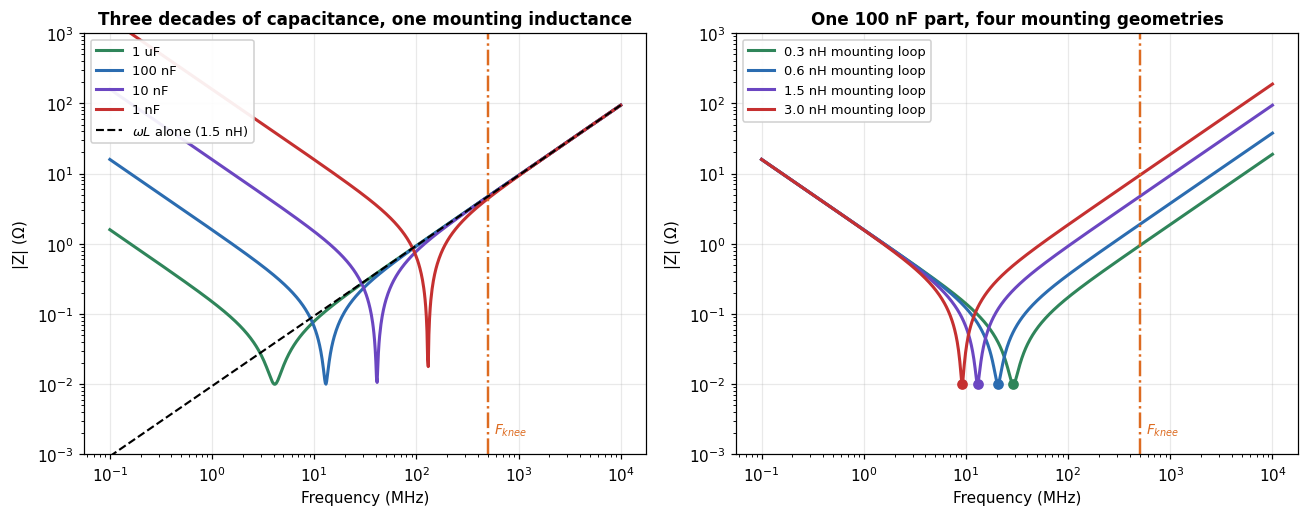

Left: above self-resonance every value collapses onto the same wL line. Changing the part
number does nothing there. Right: changing the FOOTPRINT moves the curve by 10x.


In [23]:
Fk_hz = 0.5/(Tr_ns*1e-9)
Cd    = C_decap_nF*1e-9
print(f"At F_knee = {Fk_hz/1e6:.0f} MHz:")
print(f"  X_C of {C_decap_nF:.0f} nF          = {1/(2*np.pi*Fk_hz*Cd)*1000:.2f} mohm   (irrelevant)")
print(f"  X_L of {L_mount_nH} nH mounting  = {2*np.pi*Fk_hz*L_mount_nH*1e-9:.2f} ohm      (everything)")
print()

def z_cap(f, C_F, L_H, esr=0.010):
    w = 2*np.pi*f
    return np.abs(esr + 1j*(w*L_H - 1/(w*C_F)))

f = np.logspace(5, 10, 800)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

ax = axes[0]
for Cv, col in zip([1e-6, 1e-7, 1e-8, 1e-9], [CG, CB, CP, CR]):
    ax.loglog(f/1e6, z_cap(f, Cv, L_mount_nH*1e-9), lw=2, color=col,
              label='%s' % ('1 uF' if Cv == 1e-6 else ('%g nF' % (Cv*1e9))))
ax.loglog(f/1e6, 2*np.pi*f*L_mount_nH*1e-9, 'k--', lw=1.4, label='$\\omega L$ alone (%.1f nH)' % L_mount_nH)
ax.axvline(Fk_hz/1e6, color=CO, ls='-.', lw=1.6)
ax.text(Fk_hz/1e6*1.15, 0.002, '$F_{knee}$', color=CO, fontsize=9)
ax.set_xlabel('Frequency (MHz)'); ax.set_ylabel('|Z| ($\\Omega$)')
ax.set_title('Three decades of capacitance, one mounting inductance')
ax.legend(fontsize=8.5, loc='upper left'); ax.set_ylim(1e-3, 1e3)

ax = axes[1]
for Lm, col in zip([0.3, 0.6, 1.5, 3.0], [CG, CB, CP, CR]):
    ax.loglog(f/1e6, z_cap(f, Cd, Lm*1e-9), lw=2, color=col, label='%.1f nH mounting loop' % Lm)
    fsr = 1/(2*np.pi*np.sqrt(Cd*Lm*1e-9))
    ax.plot(fsr/1e6, z_cap(np.array([fsr]), Cd, Lm*1e-9)[0], 'o', color=col, ms=6)
ax.axvline(Fk_hz/1e6, color=CO, ls='-.', lw=1.6)
ax.text(Fk_hz/1e6*1.15, 0.002, '$F_{knee}$', color=CO, fontsize=9)
ax.set_xlabel('Frequency (MHz)'); ax.set_ylabel('|Z| ($\\Omega$)')
ax.set_title('One %.0f nF part, four mounting geometries' % C_decap_nF)
ax.legend(fontsize=8.5, loc='upper left'); ax.set_ylim(1e-3, 1e3)
plt.tight_layout(); plt.show()

print("Left: above self-resonance every value collapses onto the same wL line. Changing the part")
print("number does nothing there. Right: changing the FOOTPRINT moves the curve by 10x.")

---
## 8. Mutual capacitance and mutual inductance

**Mutual capacitance.** Voltage on circuit A creates an electric field; part of it terminates on
circuit B and injects current there:

$$I_m = C_m\frac{dV_A}{dt} \approx \frac{C_m \Delta V}{T_r}
\qquad\Rightarrow\qquad \text{crosstalk} = \frac{V_B}{\Delta V} = \frac{C_m R_B}{T_r}$$

**Mutual inductance.** Current in loop A creates flux that links loop B and induces a voltage:

$$V_B = L_m\frac{dI_A}{dt} = \frac{L_m \Delta V}{R_A T_r}
\qquad\Rightarrow\qquad \text{crosstalk} = \frac{V_B}{\Delta V} = \frac{L_m}{R_A T_r}$$

Note that $T_r$ is in the **denominator** in both. Crosstalk gets *worse* as edges get faster, which is
the whole point of the chapter.

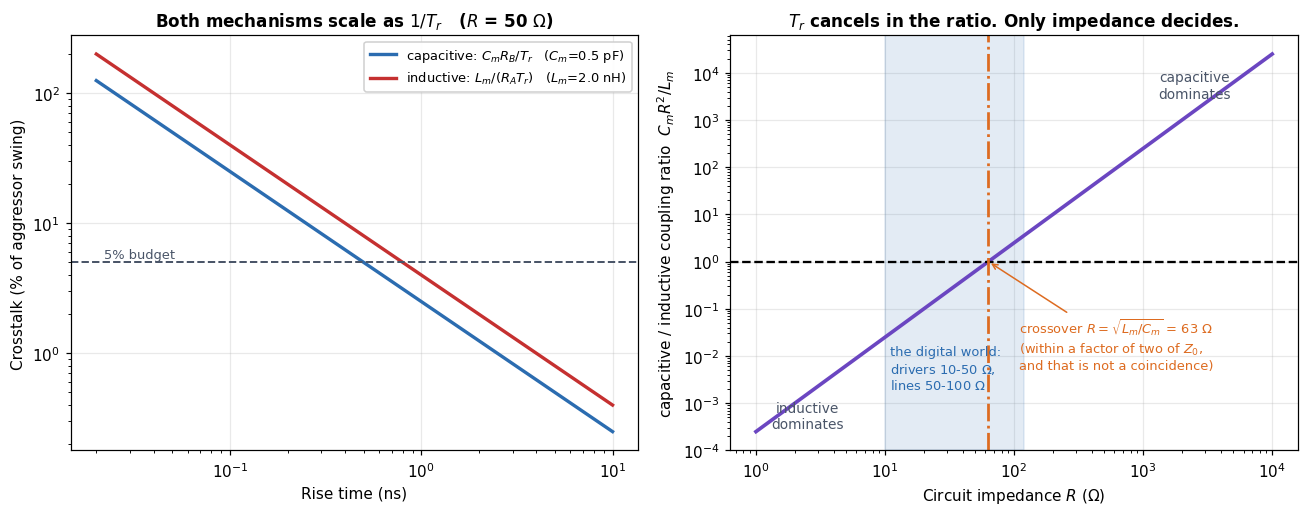

crossover impedance sqrt(Lm/Cm)   = 63 ohm
ratio at the line impedance 50 ohm = 0.62   (the two are comparable)
ratio at the driver impedance 30 ohm = 0.22   (inductive wins ~4x)
ratio at a 10 kohm analogue node = 25000   (capacitive wins by 4 decades)

The crossover always lands near the characteristic impedance of the coupled structure,
because sqrt(Lm/Cm) = Z0 * sqrt((Lm/L)/(Cm/C)) and that square root is close to 1.
So the chapter's closing claim -- 'mutual inductance is usually the worse offender' --
is really a statement about DRIVER and RETURN-PATH impedances, which sit below Z0.
It is a CONSEQUENCE of low circuit impedance, not a universal property of PCBs.


In [24]:
Cm, Lm = 0.5e-12, 2.0e-9      # representative coupled-pair values for adjacent PCB traces
def xtalk_cap(Cm, Rb, Tr_s):  return Cm*Rb/Tr_s
def xtalk_ind(Lm, Ra, Tr_s):  return Lm/(Ra*Tr_s)

trs = np.logspace(np.log10(0.02), np.log10(10), 300)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

ax = axes[0]
ax.loglog(trs, 100*xtalk_cap(Cm, Z0, trs*1e-9), lw=2.2, color=CB,
          label='capacitive: $C_m R_B/T_r$   ($C_m$=%.1f pF)' % (Cm*1e12))
ax.loglog(trs, 100*xtalk_ind(Lm, Z0, trs*1e-9), lw=2.2, color=CR,
          label='inductive: $L_m/(R_A T_r)$   ($L_m$=%.1f nH)' % (Lm*1e9))
ax.axhline(5, color=CGY, ls='--', lw=1.3); ax.text(0.022, 5.4, '5% budget', fontsize=8.5, color=CGY)
ax.set_xlabel('Rise time (ns)'); ax.set_ylabel('Crosstalk (% of aggressor swing)')
ax.set_title('Both mechanisms scale as $1/T_r$   ($R$ = %.0f $\\Omega$)' % Z0)
ax.legend(fontsize=8.5)

# --- which one dominates: the ratio is Cm R^2 / Lm, Tr cancels ---
ax = axes[1]
R = np.logspace(0, 4, 400)
ratio = Cm*R**2/Lm
ax.loglog(R, ratio, lw=2.4, color=CP)
ax.axhline(1, color='k', ls='--', lw=1.5)
Rx = np.sqrt(Lm/Cm)
ax.axvline(Rx, color=CO, ls='-.', lw=1.8)
ax.annotate('crossover $R=\\sqrt{L_m/C_m}$ = %.0f $\\Omega$\n(within a factor of two of $Z_0$,\nand that is not a coincidence)' % Rx,
            (Rx, 1), textcoords='offset points', xytext=(20, -70), fontsize=8.5, color=CO,
            arrowprops=dict(arrowstyle='->', color=CO))
ax.axvspan(10, 120, color=CB, alpha=0.13)
ax.text(11, 2e-3, 'the digital world:\ndrivers 10-50 $\\Omega$,\nlines 50-100 $\\Omega$',
        fontsize=8.5, color=CB)
ax.text(2.5e3, 3e3, 'capacitive\ndominates', fontsize=9, color=CGY, ha='center')
ax.text(2.5, 3e-4, 'inductive\ndominates', fontsize=9, color=CGY, ha='center')
ax.set_xlabel('Circuit impedance $R$ ($\\Omega$)')
ax.set_ylabel('capacitive / inductive coupling ratio  $C_m R^2/L_m$')
ax.set_title('$T_r$ cancels in the ratio. Only impedance decides.')
plt.tight_layout(); plt.show()

print(f"crossover impedance sqrt(Lm/Cm)   = {Rx:.0f} ohm")
print(f"ratio at the line impedance {Z0:.0f} ohm = {Cm*Z0**2/Lm:.2f}   (the two are comparable)")
print(f"ratio at the driver impedance {Rdrv:.0f} ohm = {Cm*Rdrv**2/Lm:.2f}   (inductive wins ~{Lm/(Cm*Rdrv**2):.0f}x)")
print(f"ratio at a 10 kohm analogue node = {Cm*1e4**2/Lm:.0f}   (capacitive wins by 4 decades)")
print()
print("The crossover always lands near the characteristic impedance of the coupled structure,")
print("because sqrt(Lm/Cm) = Z0 * sqrt((Lm/L)/(Cm/C)) and that square root is close to 1.")
print("So the chapter's closing claim -- 'mutual inductance is usually the worse offender' --")
print("is really a statement about DRIVER and RETURN-PATH impedances, which sit below Z0.")
print("It is a CONSEQUENCE of low circuit impedance, not a universal property of PCBs.")

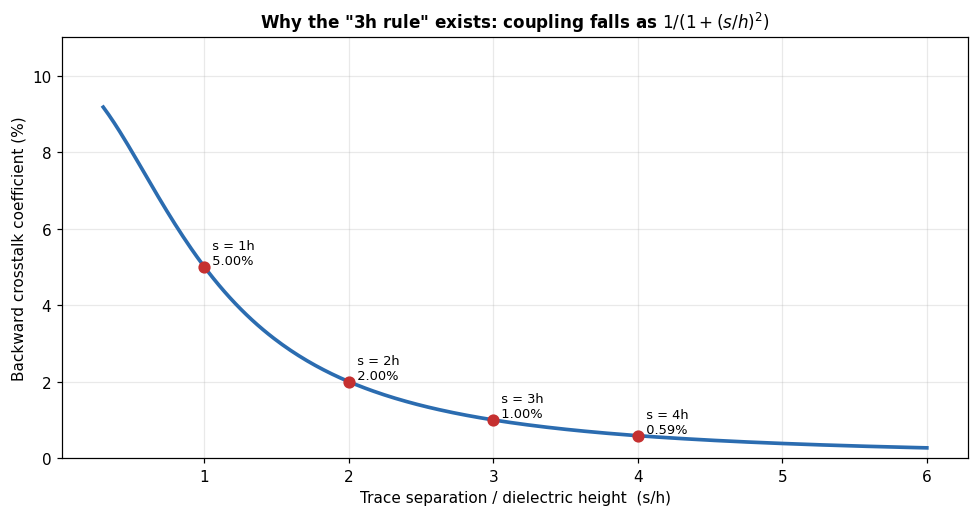

Doubling the spacing from 1h to 2h cuts coupling by 2.5x. Going to 3h cuts it 5x.
Past about 4h you are spending routing channel for very little return -- which is why
'3h' became the folk rule. Note the falloff is steep only BECAUSE a plane is close by;
without one, the fields spread and the rule collapses.


In [25]:
# Coupling falls off steeply with separation once a reference plane is present.
# Johnson's backward-crosstalk rule for microstrip: K_b proportional to 1/(1+(s/h)^2)
s_over_h = np.linspace(0.3, 6, 300)
Kb0 = 0.10   # coupling coefficient extrapolated to zero separation, typical microstrip

fig, ax = plt.subplots()
ax.plot(s_over_h, 100*Kb0/(1 + s_over_h**2), lw=2.4, color=CB)
for sh in [1, 2, 3, 4]:
    y = 100*Kb0/(1+sh**2)
    ax.plot(sh, y, 'o', color=CR, ms=7)
    ax.annotate('  s = %dh\n  %.2f%%' % (sh, y), (sh, y), fontsize=8.5, va='bottom')
ax.set_xlabel('Trace separation / dielectric height  (s/h)')
ax.set_ylabel('Backward crosstalk coefficient (%)')
ax.set_title('Why the "3h rule" exists: coupling falls as $1/(1+(s/h)^2)$')
ax.set_ylim(0, 11)
plt.tight_layout(); plt.show()

print("Doubling the spacing from 1h to 2h cuts coupling by 2.5x. Going to 3h cuts it 5x.")
print("Past about 4h you are spending routing channel for very little return -- which is why")
print("'3h' became the folk rule. Note the falloff is steep only BECAUSE a plane is close by;")
print("without one, the fields spread and the rule collapses.")

---
## 9. Why near-end and far-end crosstalk behave differently

The two mutual terms together produce all crosstalk, and their relative **polarity** is what makes the
two ends behave nothing alike.

Capacitively coupled current enters the victim node and divides, travelling both directions with the
same polarity. Inductively coupled current circulates: by Lenz's law it opposes the aggressor current,
so it flows *backward* on the victim.

- **Backward (NEXT)**, toward the victim's driver: the two contributions **add**.
  $K_b = \tfrac{1}{4}\left(\tfrac{C_m}{C} + \tfrac{L_m}{L}\right)$
- **Forward (FEXT)**, toward the victim's receiver: they **subtract**.
  $K_f = -\tfrac{1}{2}\left(\tfrac{L_m}{L} - \tfrac{C_m}{C}\right)$

**Stripline** sits in homogeneous dielectric, so $C_m/C = L_m/L$: the terms cancel and FEXT is
theoretically zero. **Microstrip** sits in FR-4 and air. Magnetic fields largely ignore the dielectric
boundary so $L_m$ stays strong, while part of the electric field runs through low-permittivity air,
weakening $C_m$. The imbalance blocks cancellation and FEXT accumulates linearly with length.

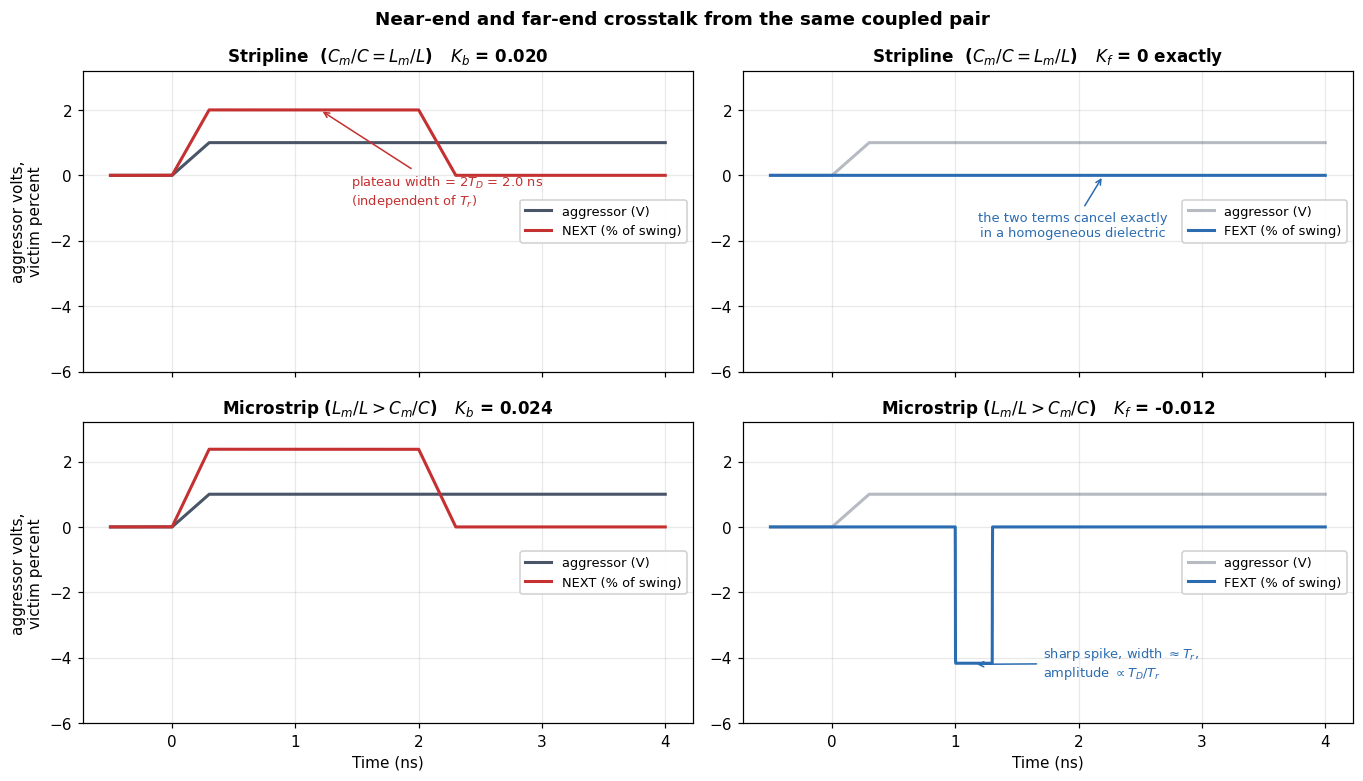

Stripline: NEXT is a long low plateau; FEXT is identically zero because the terms cancel.
Microstrip: NEXT is slightly larger, and FEXT is a sharp spike arriving exactly with the edge.


In [26]:
def crosstalk_waveforms(t, Tr, TD, Kb, Kf):
    "Weak-coupling NEXT and FEXT for a ramp aggressor."
    Va   = np.clip(t/Tr, 0, 1)
    Vd   = np.gradient(Va, t)
    next_ = Kb*(np.clip(t/Tr, 0, 1) - np.clip((t-2*TD)/Tr, 0, 1))
    fext  = Kf*TD*np.interp(t-TD, t, Vd)
    return Va, next_, fext

Tr_x, TD_x = 0.3, 1.0         # 300 ps edge, 1 ns line (about 5.7 in of stripline)
t = np.linspace(-0.5, 4, 6000)

CASES = [('Stripline  ($C_m/C = L_m/L$)',   0.040, 0.040, CG),
         ('Microstrip ($L_m/L > C_m/C$)',   0.035, 0.060, CO)]

fig, axes = plt.subplots(2, 2, figsize=(12.5, 7.2), sharex=True)
for row, (lab, CmC, LmL, col) in enumerate(CASES):
    Kb = 0.25*(CmC + LmL)
    Kf = -0.5*(LmL - CmC)
    Va, nx, fx = crosstalk_waveforms(t, Tr_x, TD_x, Kb, Kf)

    ax = axes[row][0]
    ax.plot(t, Va, lw=2, color=CGY, label='aggressor (V)')
    ax.plot(t, 100*nx, lw=2, color=CR, label='NEXT (% of swing)')
    ax.set_ylabel('aggressor volts,\nvictim percent')
    ax.set_title('%s   $K_b$ = %.3f' % (lab, Kb))
    ax.legend(fontsize=8.5, loc='center right'); ax.set_ylim(-6, 3.2)

    ax = axes[row][1]
    ax.plot(t, Va, lw=2, color=CGY, alpha=0.4, label='aggressor (V)')
    ax.plot(t, 100*fx, lw=2, color=CB, label='FEXT (% of swing)')
    ax.set_title('%s   $K_f$ = %s' % (lab, ('0 exactly' if abs(Kf) < 1e-12 else '%.3f' % Kf)))
    ax.legend(fontsize=8.5, loc='center right')
    ax.set_ylim(-6, 3.2)

for ax in axes[1]:
    ax.set_xlabel('Time (ns)')
axes[0][0].annotate('plateau width = $2T_D$ = %.1f ns\n(independent of $T_r$)' % (2*TD_x),
                    (1.2, 100*0.25*(0.04+0.04)), textcoords='offset points',
                    xytext=(20, -62), fontsize=8.5, color=CR,
                    arrowprops=dict(arrowstyle='->', color=CR))
axes[0][1].annotate('the two terms cancel exactly\nin a homogeneous dielectric',
                    (2.2, 0), textcoords='offset points', xytext=(-20, -40),
                    fontsize=8.5, color=CB, ha='center',
                    arrowprops=dict(arrowstyle='->', color=CB))
axes[1][1].annotate('sharp spike, width $\\approx T_r$,\namplitude $\\propto T_D/T_r$',
                    (TD_x+Tr_x/2, -4.2), textcoords='offset points',
                    xytext=(45, -8), fontsize=8.5, color=CB,
                    arrowprops=dict(arrowstyle='->', color=CB))
plt.suptitle('Near-end and far-end crosstalk from the same coupled pair', fontweight='bold')
plt.tight_layout(); plt.show()

print("Stripline: NEXT is a long low plateau; FEXT is identically zero because the terms cancel.")
print("Microstrip: NEXT is slightly larger, and FEXT is a sharp spike arriving exactly with the edge.")

### The saturation length

NEXT amplitude grows with parallel run length until the run exceeds half the spatial length of the
edge, then it **saturates**:

$$L_{sat} = \frac{T_r \times v}{2}$$

Past that, a longer parallel run does not make near-end crosstalk worse. It makes the noise pulse
*wider*, not taller. This is why "shorten the parallel run" as a fix stops working after an inch or
two, and why separation and reference-plane proximity are the real levers.

FEXT has no such mercy: it grows **linearly** with parallel length, without limit.

NEXT saturation length, L_sat = Tr*v/2
Tr (ps)  L_sat stripline (in)  L_sat microstrip (in)
-------  --------------------  ---------------------
5000     14.23                 16.75                
2000     5.69                  6.70                 
1000     2.85                  3.35                 
500      1.42                  1.68                 
300      0.85                  1.01                 
100      0.28                  0.34                 
30       0.09                  0.10                 



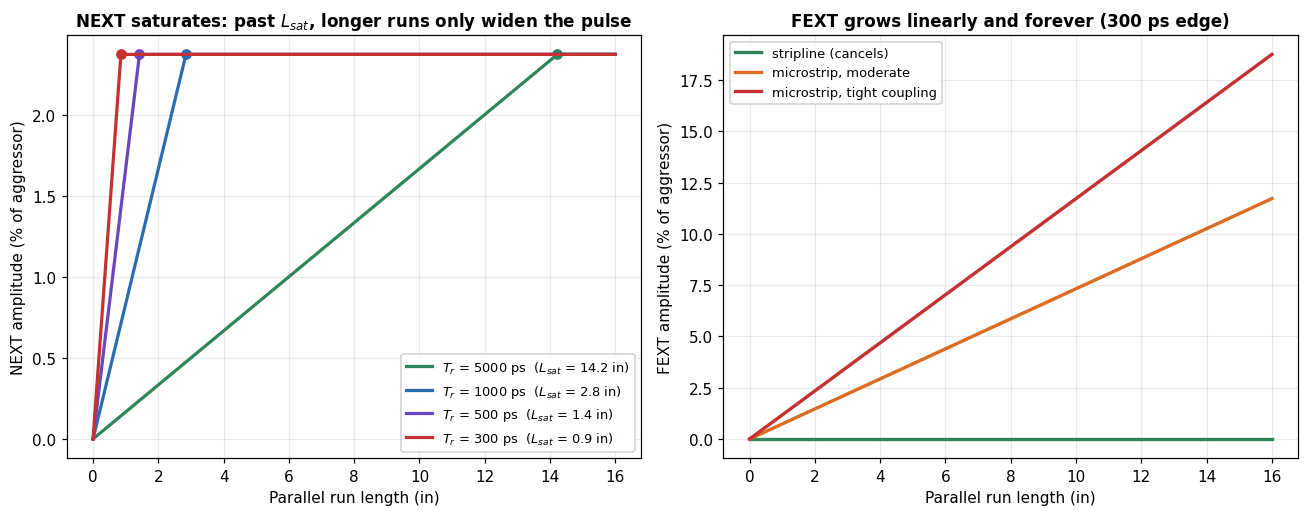

Design consequence: long parallel runs of edge-sensitive signals belong on STRIPLINE.
Burying a six-inch bus does not merely reduce far-end crosstalk -- it can remove the
mechanism. Surface routing keeps FEXT on the table permanently.

NEXT vs FEXT
                   NEXT                      FEXT                    
-----------------  ------------------------  ------------------------
Direction          backward, to the driver   forward, to the receiver
Superposition      C_m + L_m (constructive)  C_m - L_m (destructive) 
Length dependence  saturates past Tr*v/2     grows linearly          
Stripline          high                      near zero               
Microstrip         very high                 moderate to high        
Pulse shape        plateau, width 2*TD       spike, width ~Tr        



In [27]:
rows = [[f"{tr*1000:.0f}", f"{tr*v_stripline/2:.2f}", f"{tr*v_microstrip/2:.2f}"]
        for tr in Tr_list]
table(rows, ['Tr (ps)', 'L_sat stripline (in)', 'L_sat microstrip (in)'],
      'NEXT saturation length, L_sat = Tr*v/2')

L = np.linspace(0, 16, 400)     # inches of parallel run
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

ax = axes[0]
for tr, col in zip([5.0, 1.0, 0.5, 0.3], [CG, CB, CP, CR]):
    Lsat = tr*v_stripline/2
    Kb   = 0.25*(0.035+0.060)
    ax.plot(L, 100*Kb*np.minimum(L/Lsat, 1.0), lw=2.1, color=col,
            label='$T_r$ = %.0f ps  ($L_{sat}$ = %.1f in)' % (tr*1000, Lsat))
    ax.plot(Lsat, 100*Kb, 'o', color=col, ms=6)
ax.set_xlabel('Parallel run length (in)'); ax.set_ylabel('NEXT amplitude (% of aggressor)')
ax.set_title('NEXT saturates: past $L_{sat}$, longer runs only widen the pulse')
ax.legend(fontsize=8.5)

ax = axes[1]
for CmC, LmL, lab, col in [(0.040, 0.040, 'stripline (cancels)', CG),
                           (0.035, 0.060, 'microstrip, moderate', CO),
                           (0.030, 0.070, 'microstrip, tight coupling', CR)]:
    Kf = -0.5*(LmL - CmC)
    TDl = L*D_stripline/1000.0                 # ns of delay for that length
    amp = 100*np.abs(Kf)*TDl/0.3               # for a 300 ps edge
    ax.plot(L, amp, lw=2.2, color=col, label=lab)
ax.set_xlabel('Parallel run length (in)'); ax.set_ylabel('FEXT amplitude (% of aggressor)')
ax.set_title('FEXT grows linearly and forever (300 ps edge)')
ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

print("Design consequence: long parallel runs of edge-sensitive signals belong on STRIPLINE.")
print("Burying a six-inch bus does not merely reduce far-end crosstalk -- it can remove the")
print("mechanism. Surface routing keeps FEXT on the table permanently.")
print()
table([['Direction',        'backward, to the driver', 'forward, to the receiver'],
       ['Superposition',    'C_m + L_m (constructive)', 'C_m - L_m (destructive)'],
       ['Length dependence','saturates past Tr*v/2',    'grows linearly'],
       ['Stripline',        'high',                     'near zero'],
       ['Microstrip',       'very high',                'moderate to high'],
       ['Pulse shape',      'plateau, width 2*TD',      'spike, width ~Tr']],
      ['', 'NEXT', 'FEXT'], 'NEXT vs FEXT')

---
## 10. What eats the edge on long runs

Once spectral content pushes into the gigahertz, the lossless-conductor and perfect-dielectric
assumptions fail through three mechanisms.

### 10.1 Skin effect

Time-varying current generates an internal magnetic field that induces eddy currents opposing flow at
the centre of the conductor and reinforcing it at the perimeter. Current migrates outward into a
surface layer of depth

$$\delta = \sqrt{\frac{\rho}{\pi\mu f}}$$

Effective cross-section shrinks as $1/\sqrt{f}$, so AC resistance rises as $\sqrt{f}$. **The DC
resistance in a wire table is close to useless for estimating high-frequency loss.**

         1 MHz  ->  delta =  66.01 um   (188.6% of 35 um copper)
       100 MHz  ->  delta =   6.60 um   ( 18.9% of 35 um copper)
       500 MHz  ->  delta =   2.95 um   (  8.4% of 35 um copper)
      1000 MHz  ->  delta =   2.09 um   (  6.0% of 35 um copper)
     10000 MHz  ->  delta =   0.66 um   (  1.9% of 35 um copper)



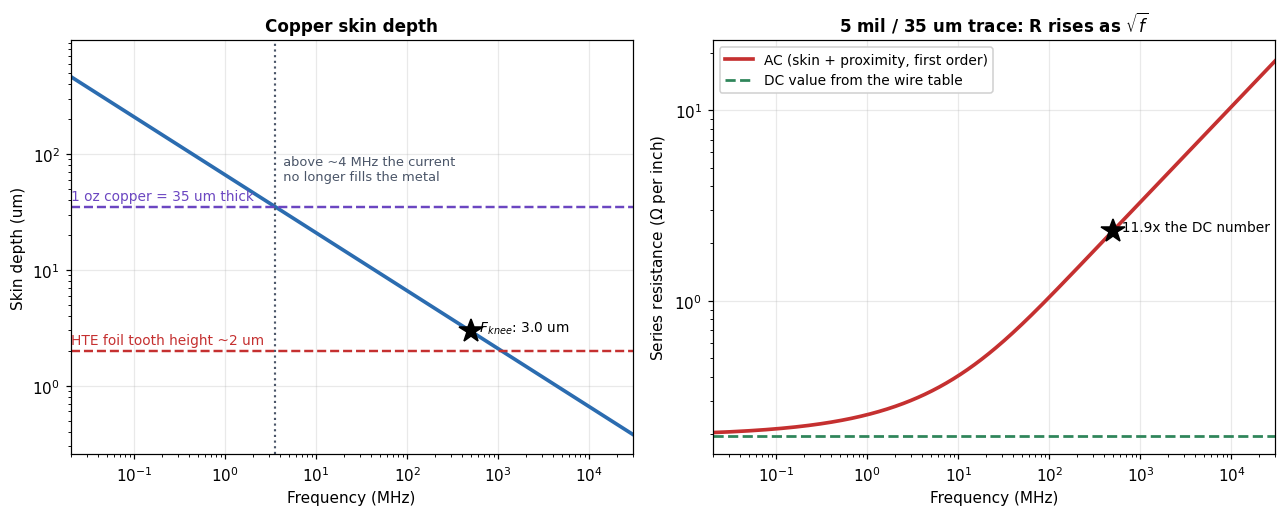

In [28]:
def skin_depth(f, rho=rho_cu, mu=mu0):
    return np.sqrt(rho/(np.pi*mu*np.asarray(f, dtype=float)))

for fq in [1e6, 1e8, 5e8, 1e9, 1e10]:
    d = skin_depth(fq)
    print(f"  {fq/1e6:8.0f} MHz  ->  delta = {d*1e6:6.2f} um   "
          f"({100*d*1e6/t_cu_um:5.1f}% of {t_cu_um:.0f} um copper)")
print()

f = np.logspace(4, 10.5, 500)
d = skin_depth(f)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ax = axes[0]
ax.loglog(f/1e6, d*1e6, lw=2.4, color=CB)
ax.axhline(t_cu_um, color=CP, ls='--', lw=1.6)
ax.text(0.02, t_cu_um*1.15, '1 oz copper = %.0f um thick' % t_cu_um, color=CP, fontsize=9)
ax.axhline(Rq_um, color=CR, ls='--', lw=1.6)
ax.text(0.02, Rq_um*1.15, 'HTE foil tooth height ~%.0f um' % Rq_um, color=CR, fontsize=9)
f_eq = rho_cu/(np.pi*mu0*(t_cu_um*1e-6)**2)
ax.axvline(f_eq/1e6, color=CGY, ls=':', lw=1.4)
ax.annotate('  above ~%.0f MHz the current\n  no longer fills the metal' % (f_eq/1e6),
            (f_eq/1e6, 60), fontsize=8.5, color=CGY)
Fk_hz = 0.5/(Tr_ns*1e-9)
ax.plot(Fk_hz/1e6, skin_depth(Fk_hz)*1e6, '*', color='k', ms=16, zorder=5)
ax.annotate('  $F_{knee}$: %.1f um' % (skin_depth(Fk_hz)*1e6), (Fk_hz/1e6, skin_depth(Fk_hz)*1e6),
            fontsize=9)
ax.set_xlabel('Frequency (MHz)'); ax.set_ylabel('Skin depth (um)')
ax.set_title('Copper skin depth')
ax.set_xlim(0.02, 3e4)

# --- AC resistance of this board's trace ---
w_m, t_m = w_mil*MIL, t_cu_um*1e-6
R_dc = rho_cu/(w_m*t_m)                                   # ohm/m, signal conductor only
def R_ac(f, Kprox=2.0):
    dd  = skin_depth(f)
    eff = dd*(1 - np.exp(-t_m/dd))                        # blends smoothly into DC
    return Kprox*rho_cu/(w_m*eff)

ax = axes[1]
ax.loglog(f/1e6, R_ac(f)*IN, lw=2.4, color=CR, label='AC (skin + proximity, first order)')
ax.axhline(2*R_dc*IN, color=CG, ls='--', lw=1.8, label='DC value from the wire table')
ax.plot(Fk_hz/1e6, R_ac(Fk_hz)*IN, '*', color='k', ms=16, zorder=5)
ax.annotate('  %.1fx the DC number' % (R_ac(Fk_hz)/(2*R_dc)), (Fk_hz/1e6, R_ac(Fk_hz)*IN), fontsize=9)
ax.set_xlabel('Frequency (MHz)'); ax.set_ylabel('Series resistance ($\\Omega$ per inch)')
ax.set_title('%.0f mil / %.0f um trace: R rises as $\\sqrt{f}$' % (w_mil, t_cu_um))
ax.legend(fontsize=9, loc='upper left'); ax.set_xlim(0.02, 3e4)
plt.tight_layout(); plt.show()

### 10.2 Dielectric loss

The laminate is an imperfect insulator. Alternating fields force polarised molecular dipoles in the
resin to reorient continuously, and that molecular friction converts signal energy into heat.
Dielectric loss grows roughly **linearly** with frequency:

$$\alpha_d \approx 2.3\,f_{GHz}\sqrt{\varepsilon_{r,eff}}\,\tan\delta \quad \text{dB/inch}$$

It starts below skin-effect loss and eventually overtakes it. Above that crossover the line is
dielectric-loss-limited, which puts a hard ceiling on trace length.

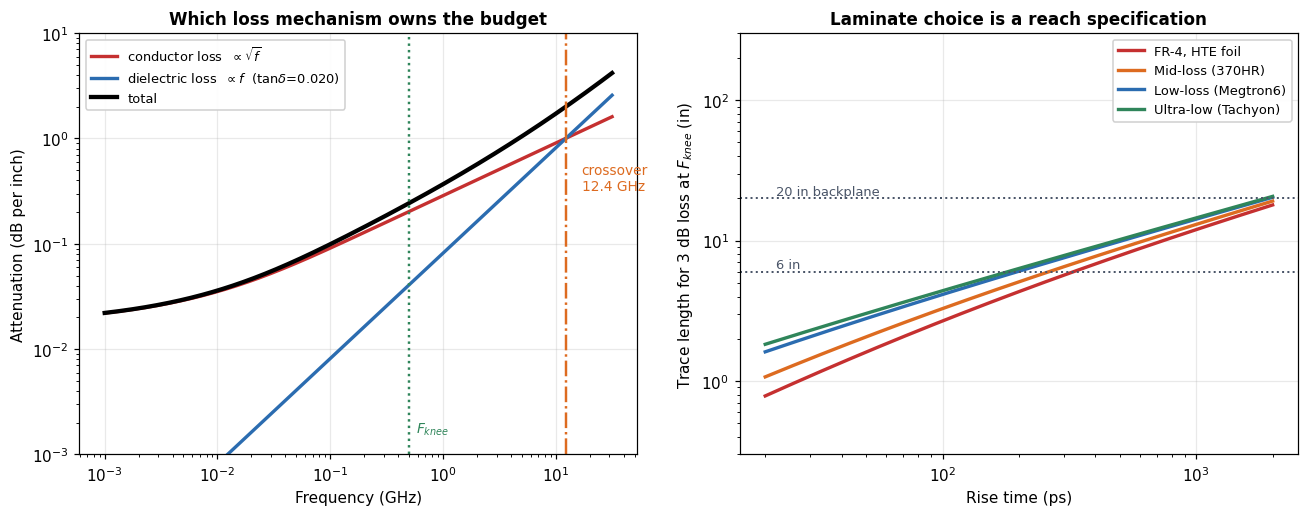

Crossover for this 5 mil trace on FR-4: 12.4 GHz.

Note how weakly the right-hand plot separates the laminates. On a trace this narrow,
CONDUCTOR loss sets the floor, and it is identical for all four materials -- so the
exotic laminate buys only about 2x of reach. Widen the trace first, then buy the
laminate. The crossover frequency itself moves down as the trace gets wider, because
wider copper cuts the sqrt(f) term while leaving the linear-in-f term untouched.


In [29]:
def alpha_c_db_in(f, Z0=Z0):
    return 8.686*R_ac(f)/(2*Z0)*IN

def alpha_d_db_in(f, er_eff=er_eff_ustrip, td=tan_d):
    return 8.686*np.pi*np.asarray(f, float)*np.sqrt(er_eff)*td/c_m_s*IN

f = np.logspace(6, 10.5, 600)
ac, ad = alpha_c_db_in(f), alpha_d_db_in(f)
fx = f[np.argmin(np.abs(ac-ad))]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ax = axes[0]
ax.loglog(f/1e9, ac, lw=2.2, color=CR, label='conductor loss  $\\propto\\sqrt{f}$')
ax.loglog(f/1e9, ad, lw=2.2, color=CB, label='dielectric loss  $\\propto f$  (tan$\\delta$=%.3f)' % tan_d)
ax.loglog(f/1e9, ac+ad, lw=2.8, color='k', label='total')
ax.axvline(fx/1e9, color=CO, ls='-.', lw=1.6)
ax.annotate('crossover\n%.1f GHz' % (fx/1e9), (fx/1e9, ac[np.argmin(np.abs(ac-ad))]),
            textcoords='offset points', xytext=(10, -34), fontsize=9, color=CO)
ax.axvline(Fk_hz/1e9, color=CG, ls=':', lw=1.6)
ax.text(Fk_hz/1e9*1.15, 1.6e-3, '$F_{knee}$', color=CG, fontsize=9)
ax.set_xlabel('Frequency (GHz)'); ax.set_ylabel('Attenuation (dB per inch)')
ax.set_title('Which loss mechanism owns the budget')
ax.legend(fontsize=8.5, loc='upper left'); ax.set_ylim(1e-3, 10)

# --- reach: how long a trace can be before it eats 3 dB at F_knee ---
ax = axes[1]
LAM = [('FR-4, HTE foil',      4.3, 0.020, CR),
       ('Mid-loss (370HR)',    3.9, 0.012, CO),
       ('Low-loss (Megtron6)', 3.4, 0.004, CB),
       ('Ultra-low (Tachyon)', 3.0, 0.0021, CG)]
trs = np.logspace(np.log10(0.02), np.log10(2), 200)
for lab, er, td, col in LAM:
    fk = 0.5/(trs*1e-9)
    tot = alpha_c_db_in(fk) + alpha_d_db_in(fk, er, td)
    ax.loglog(trs*1000, 3.0/tot, lw=2.2, color=col, label=lab)
ax.axhline(6, color=CGY, ls=':', lw=1.3); ax.text(22, 6.4, '6 in', fontsize=8.5, color=CGY)
ax.axhline(20, color=CGY, ls=':', lw=1.3); ax.text(22, 21, '20 in backplane', fontsize=8.5, color=CGY)
ax.set_xlabel('Rise time (ps)'); ax.set_ylabel('Trace length for 3 dB loss at $F_{knee}$ (in)')
ax.set_title('Laminate choice is a reach specification')
ax.legend(fontsize=8.5); ax.set_ylim(0.3, 300)
plt.tight_layout(); plt.show()

print(f"Crossover for this {w_mil:.0f} mil trace on FR-4: {fx/1e9:.1f} GHz.")
print()
print("Note how weakly the right-hand plot separates the laminates. On a trace this narrow,")
print("CONDUCTOR loss sets the floor, and it is identical for all four materials -- so the")
print("exotic laminate buys only about 2x of reach. Widen the trace first, then buy the")
print("laminate. The crossover frequency itself moves down as the trace gets wider, because")
print("wider copper cuts the sqrt(f) term while leaving the linear-in-f term untouched.")

### 10.3 Surface roughness

Copper foil is deliberately roughened for adhesion to the laminate. Once skin depth drops below the
tooth profile, current is forced to follow the jagged contour, lengthening the effective path and
raising resistance. At 500 MHz the skin depth is ~2.9 um and standard HTE foil has teeth of
comparable size, so this is **not** an exotic multi-gigahertz concern.

The historical model is **Hammerstad-Jensen**, which scales smooth-copper resistance by a factor
derived from a single RMS tooth height:

$$K_{HJ} = 1 + \frac{2}{\pi}\arctan\!\left[1.4\left(\frac{R_q}{\delta}\right)^2\right]$$

It saturates at 2 and then fails badly above about 5 GHz, predicting a ceiling on loss that
underestimates real attenuation. **Huray** replaced it with a physics-based scattering model built
from SEM imagery, treating the electrodeposited surface as a field of conductive spheres (the
"snowball" model) on a matte base:

$$K_{H} = 1 + \frac{A_{spheres}}{A_{flat}}\cdot\frac{1}{1 + \delta/r + \delta^2/2r^2}$$

which keeps rising. Because measuring the sphere radii requires destructive cross-sectioning,
Simonovich's **Cannonball-Huray** adaptation assumes hexagonal close packing and derives the
parameters from the roughness numbers already on the laminate datasheet.

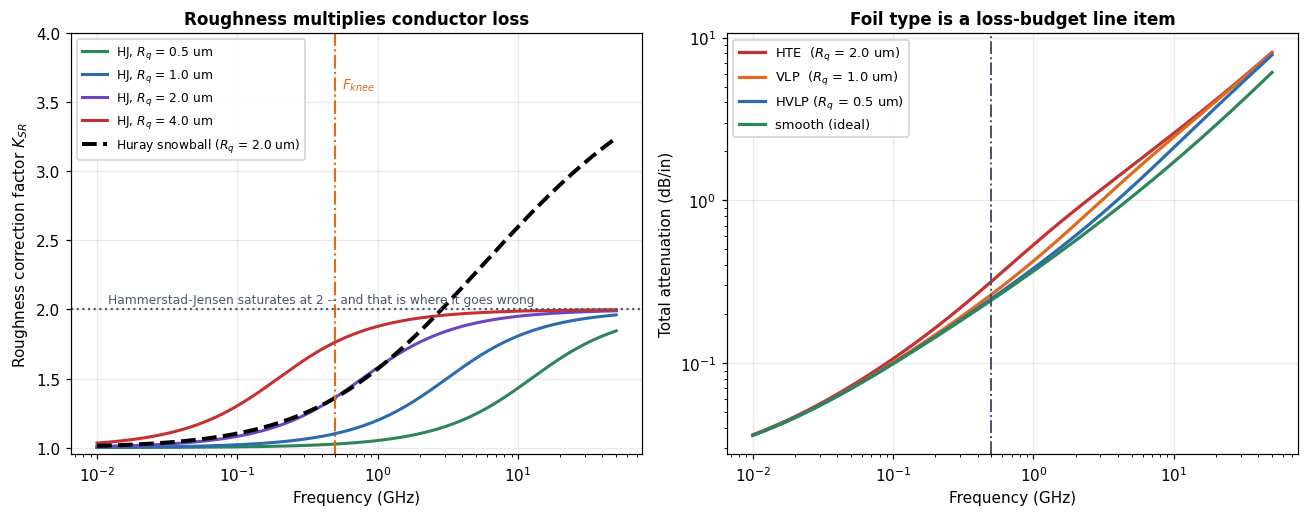

Loss at 10 GHz, 10-inch trace:
  HTE  ($R_q$ = 2.0 um)       25.8 dB
  VLP  ($R_q$ = 1.0 um)       24.5 dB
  HVLP ($R_q$ = 0.5 um)       21.1 dB
  smooth (ideal)              17.2 dB

Substituting foil is an easy cost-down for a fabricator and a silent loss-budget change
for you. Put the foil type in the stackup spec on the fab drawing, next to the Dk.


In [30]:
def K_hammerstad(f, Rq_m):
    return 1 + (2/np.pi)*np.arctan(1.4*(Rq_m/skin_depth(f))**2)

def K_huray(f, r_m, area_ratio):
    d = skin_depth(f)
    return 1 + area_ratio/(1 + d/r_m + d**2/(2*r_m**2))

Rq_m = Rq_um*1e-6
# Cannonball-Huray fixes r and the area ratio from the datasheet Rz under HCP packing.
# Exposed here as tunables so their effect is visible rather than buried.
r_sphere   = Rq_m/2.0
area_ratio = 3.0

f = np.logspace(7, 10.7, 500)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

ax = axes[0]
for Rq_i, col in zip([0.5, 1.0, 2.0, 4.0], [CG, CB, CP, CR]):
    ax.semilogx(f/1e9, K_hammerstad(f, Rq_i*1e-6), lw=2, color=col,
                label='HJ, $R_q$ = %.1f um' % Rq_i)
ax.semilogx(f/1e9, K_huray(f, r_sphere, area_ratio), lw=2.6, color='k', ls='--',
            label='Huray snowball ($R_q$ = %.1f um)' % Rq_um)
ax.axhline(2, color=CGY, ls=':', lw=1.4)
ax.text(0.012, 2.05, 'Hammerstad-Jensen saturates at 2 -- and that is where it goes wrong',
        fontsize=8, color=CGY)
ax.axvline(Fk_hz/1e9, color=CO, ls='-.', lw=1.4)
ax.text(Fk_hz/1e9*1.12, 3.6, '$F_{knee}$', color=CO, fontsize=9)
ax.set_xlabel('Frequency (GHz)'); ax.set_ylabel('Roughness correction factor $K_{SR}$')
ax.set_title('Roughness multiplies conductor loss')
ax.legend(fontsize=8, loc='upper left'); ax.set_ylim(0.95, 4)

ax = axes[1]
FOIL = [('HTE  ($R_q$ = 2.0 um)',  2.0, CR),
        ('VLP  ($R_q$ = 1.0 um)',  1.0, CO),
        ('HVLP ($R_q$ = 0.5 um)',  0.5, CB),
        ('smooth (ideal)',         0.0, CG)]
for lab, Rq_i, col in FOIL:
    K = K_hammerstad(f, Rq_i*1e-6) if Rq_i > 0 else np.ones_like(f)
    ax.loglog(f/1e9, alpha_c_db_in(f)*K + alpha_d_db_in(f), lw=2.1, color=col, label=lab)
ax.axvline(Fk_hz/1e9, color=CGY, ls='-.', lw=1.3)
ax.set_xlabel('Frequency (GHz)'); ax.set_ylabel('Total attenuation (dB/in)')
ax.set_title('Foil type is a loss-budget line item')
ax.legend(fontsize=8.5, loc='upper left')
plt.tight_layout(); plt.show()

fk10 = 1e10
print("Loss at 10 GHz, %.0f-inch trace:" % 10)
for lab, Rq_i, col in FOIL:
    K = K_hammerstad(fk10, Rq_i*1e-6) if Rq_i > 0 else 1.0
    tot = (alpha_c_db_in(fk10)*K + alpha_d_db_in(fk10))*10
    print(f"  {lab:26s} {tot:5.1f} dB")
print()
print("Substituting foil is an easy cost-down for a fabricator and a silent loss-budget change")
print("for you. Put the foil type in the stackup spec on the fab drawing, next to the Dk.")

---
## 11. Rise-time budgets and measurement error

Cascaded roughly-Gaussian stages combine in root-sum-square:

$$T_{total} = \sqrt{\sum_i T_i^2}$$

This is the formula that says a measurement is only as good as the instrument's own edge, and that a
signal chain's slowest stage dominates. A scope's rise time is $T_{scope} \approx 0.35/BW$.

Budget for the worked example of section 6:
  driver intrinsic edge         1000 ps
  RC of 30 ohm x 10 pF           660 ps
  channel (3 dB at 2 GHz)        175 ps
  RSS total                     1211 ps



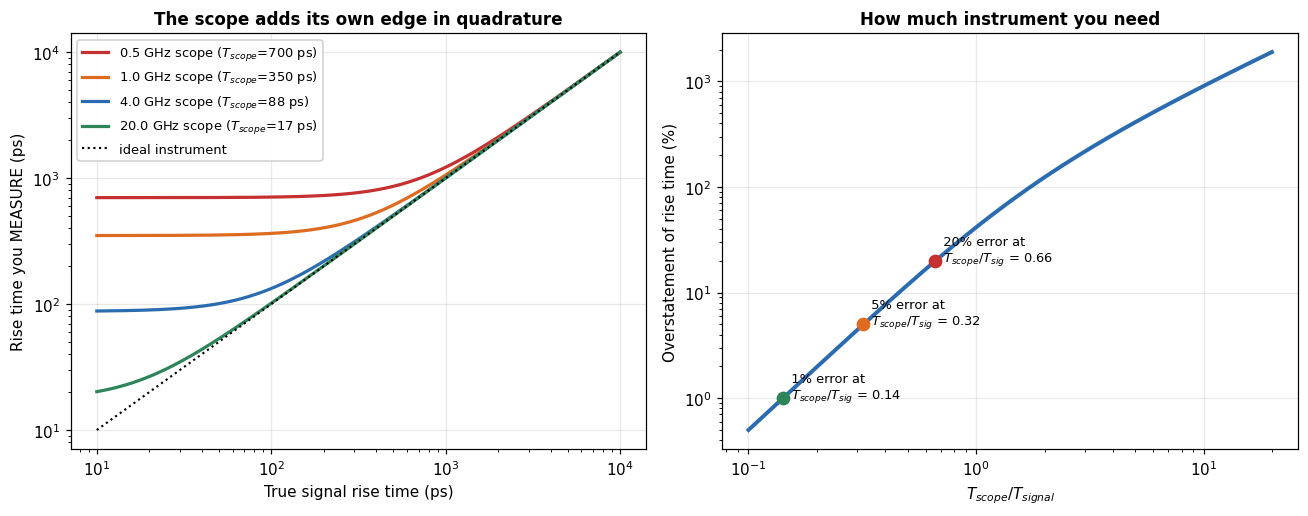

  To measure a  1000 ps edge to ~1%%, you need about   2.3 GHz of scope bandwidth.
  To measure a   300 ps edge to ~1%%, you need about   7.8 GHz of scope bandwidth.
  To measure a   100 ps edge to ~1%%, you need about  23.3 GHz of scope bandwidth.
  To measure a    30 ps edge to ~1%%, you need about  77.8 GHz of scope bandwidth.


In [31]:
def rss(*args):
    return np.sqrt(sum(np.asarray(a, dtype=float)**2 for a in args))

print("Budget for the worked example of section 6:")
parts = [('driver intrinsic edge', Tr_ns*1000),
         ('RC of 30 ohm x 10 pF',  2.2*Rdrv*C_load_pF*1e-12*1e12),
         ('channel (3 dB at 2 GHz)', 0.35/2e9*1e12)]
for lab, v in parts:
    print(f"  {lab:26s} {v:7.0f} ps")
print(f"  {'RSS total':26s} {rss(*[v for _, v in parts]):7.0f} ps")
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

ax = axes[0]
Tr_true = np.logspace(np.log10(0.01), np.log10(10), 300)   # ns
for BW, col in zip([0.5e9, 1e9, 4e9, 20e9], [CR, CO, CB, CG]):
    Ts = 0.35/BW*1e9
    ax.loglog(Tr_true*1000, rss(Tr_true, Ts)*1000, lw=2.1, color=col,
              label='%.1f GHz scope ($T_{scope}$=%.0f ps)' % (BW/1e9, Ts*1000))
ax.loglog(Tr_true*1000, Tr_true*1000, 'k:', lw=1.4, label='ideal instrument')
ax.set_xlabel('True signal rise time (ps)'); ax.set_ylabel('Rise time you MEASURE (ps)')
ax.set_title('The scope adds its own edge in quadrature')
ax.legend(fontsize=8.5, loc='upper left')

ax = axes[1]
ratio = np.logspace(-1, 1.3, 300)          # T_scope / T_signal
err   = 100*(np.sqrt(1 + ratio**2) - 1)
ax.loglog(ratio, err, lw=2.6, color=CB)
for lim, lab, col in [(1, '1%', CG), (5, '5%', CO), (20, '20%', CR)]:
    rr = np.interp(lim, err, ratio)
    ax.plot(rr, lim, 'o', color=col, ms=8)
    ax.annotate('  %s error at\n  $T_{scope}/T_{sig}$ = %.2f' % (lab, rr), (rr, lim), fontsize=8.5)
ax.set_xlabel('$T_{scope} / T_{signal}$'); ax.set_ylabel('Overstatement of rise time (%)')
ax.set_title('How much instrument you need')
plt.tight_layout(); plt.show()

for Tr_sig_ps in [1000, 300, 100, 30]:
    bw_needed = 0.35/(0.15*Tr_sig_ps*1e-12)      # scope Tr <= 0.15 x signal -> ~1% error
    print(f"  To measure a {Tr_sig_ps:5.0f} ps edge to ~1%%, you need about {bw_needed/1e9:5.1f} GHz "
          f"of scope bandwidth.")

---
## 12. Two lab jigs from the chapter

### 12.1 Measuring capacitance

Drive the unknown capacitance through a known source resistance $R_s$ and read the 10-90% rise time:

$$T_r = 2.2 R_s C \quad\Rightarrow\quad C = \frac{T_r}{2.2 R_s}$$

**Subtract the instrument contributions in RSS before back-calculating.** If the generator and scope
contribute comparable rise times, the raw number is badly wrong.

In [32]:
C_true  = 10e-12
Rs_jig  = 1000.0
Tr_c    = 2.2*Rs_jig*C_true                    # s

rows = []
for BW, Tgen_ps in [(20e9, 20), (4e9, 100), (1e9, 300), (0.5e9, 800)]:
    Tsc  = 0.35/BW
    Tmeas = np.sqrt(Tr_c**2 + Tsc**2 + (Tgen_ps*1e-12)**2)
    C_raw = Tmeas/(2.2*Rs_jig)
    C_cor = np.sqrt(max(Tmeas**2 - Tsc**2 - (Tgen_ps*1e-12)**2, 0))/(2.2*Rs_jig)
    rows.append([f"{BW/1e9:.1f}", f"{Tgen_ps:.0f}", f"{Tmeas*1e12:.0f}",
                 f"{C_raw*1e12:.2f}", f"{100*(C_raw/C_true-1):+.1f}%",
                 f"{C_cor*1e12:.2f}"])
table(rows, ['scope BW (GHz)', 'gen Tr (ps)', 'measured Tr (ps)',
             'C raw (pF)', 'raw error', 'C after RSS (pF)'],
      f'Capacitance jig: true C = {C_true*1e12:.0f} pF, Rs = {Rs_jig:.0f} ohm')

print(f"Keep Rs large enough that the RC dominates the generator's own edge ({Tr_c*1e12:.0f} ps here),")
print("and small enough that fixture stray capacitance stays negligible.")

Capacitance jig: true C = 10 pF, Rs = 1000 ohm
scope BW (GHz)  gen Tr (ps)  measured Tr (ps)  C raw (pF)  raw error  C after RSS (pF)
--------------  -----------  ----------------  ----------  ---------  ----------------
20.0            20           22000             10.00       +0.0%      10.00           
4.0             100          22000             10.00       +0.0%      10.00           
1.0             300          22005             10.00       +0.0%      10.00           
0.5             800          22026             10.01       +0.1%      10.00           

Keep Rs large enough that the RC dominates the generator's own edge (22000 ps here),
and small enough that fixture stray capacitance stays negligible.


### 12.2 Measuring inductance: the area method

Drive a fast step into the inductance in series with a resistor $R$; the scope sees a voltage spike
decaying with $\tau = L/R$. Rather than eyeballing the decay, **integrate**:

$$\text{Area} = \int_0^\infty V_0 e^{-t/\tau}\,dt = V_0\tau
\quad\Rightarrow\quad \tau = \frac{\text{Area}}{V_0},\qquad L = \tau R$$

Why this is the right technique: **a slow generator edge or a bandwidth-limited scope smears the
waveform but preserves its area.** Integration is linear, and any DC-accurate measuring system has
unit area in its impulse response. The area measurement is immune to exactly the instrument
limitations that corrupt a direct time-constant reading.

This is the single most useful lab trick in the chapter. (Caveat: it depends on the scope's DC path.
**AC coupling destroys the measurement.**)

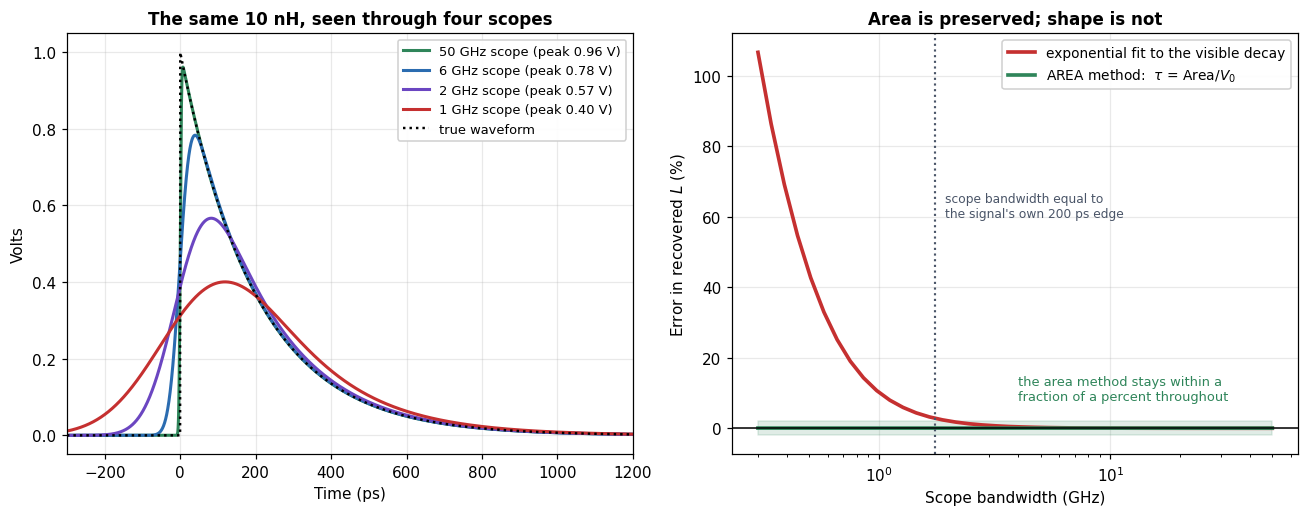

Recovering L = 10 nH (tau = 200 ps, R = 50 ohm)
BW (GHz)  peak (V)  tau from fit (ps)  fit error  tau from area (ps)  area error  L from area (nH)
--------  --------  -----------------  ---------  ------------------  ----------  ----------------
50        0.961     200                +0.0%      200.1               +0.06%      10.006          
6         0.783     200                +0.2%      200.1               +0.06%      10.006          
2         0.567     204                +2.1%      200.1               +0.06%      10.006          
1         0.401     220                +10.2%     200.1               +0.06%      10.006          

The peak amplitude collapses and the apparent time constant drifts, but the integral
holds to a fraction of a percent all the way down to a scope with less bandwidth than
the signal. Measure the area.


In [33]:
L_true, R_jig = 10e-9, 50.0
tau_true = L_true/R_jig                   # 200 ps
V0 = 1.0

# The record must start well BEFORE the step, otherwise scope smearing pushes area off the
# left edge of the window and the area method looks broken when it is the simulation that is.
t  = np.linspace(-10*tau_true, 40*tau_true, 25000)
v_ideal = np.where(t >= 0, V0*np.exp(-t/tau_true), 0.0)

def scope_smear(v, t, Tr_scope):
    "Convolve with a Gaussian impulse response of the given 10-90% rise time (unit area)."
    if Tr_scope <= 0:
        return v.copy()
    sigma = Tr_scope/2.563                # 10-90% of a Gaussian step = 2.563 sigma
    tt = t - t.mean()
    g  = np.exp(-0.5*(tt/sigma)**2)
    g /= g.sum()
    return np.convolve(v, g, mode='same')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ax = axes[0]
rows = []
for BW, col in zip([50e9, 6e9, 2e9, 1e9], [CG, CB, CP, CR]):
    Tsc = 0.35/BW
    vs  = scope_smear(v_ideal, t, Tsc)
    area = np.trapz(vs, t)
    tau_area = area/V0
    mask = (vs > 0.05*vs.max()) & (t > t[np.argmax(vs)])
    if mask.sum() > 10:
        p = np.polyfit(t[mask], np.log(vs[mask]), 1)
        tau_fit = -1/p[0]
    else:
        tau_fit = np.nan
    ax.plot(t*1e12, vs, lw=2, color=col,
            label='%.0f GHz scope (peak %.2f V)' % (BW/1e9, vs.max()))
    rows.append([f"{BW/1e9:.0f}", f"{vs.max():.3f}",
                 f"{tau_fit*1e12:.0f}", f"{100*(tau_fit/tau_true-1):+.1f}%",
                 f"{tau_area*1e12:.1f}", f"{100*(tau_area/tau_true-1):+.2f}%",
                 f"{tau_area*R_jig*1e9:.3f}"])
ax.plot(t*1e12, v_ideal, 'k:', lw=1.6, label='true waveform')
ax.set_xlabel('Time (ps)'); ax.set_ylabel('Volts')
ax.set_xlim(-300, 1200)
ax.set_title('The same %.0f nH, seen through four scopes' % (L_true*1e9))
ax.legend(fontsize=8.5)

ax = axes[1]
BWs = np.logspace(np.log10(0.3e9), np.log10(50e9), 40)
e_area, e_fit = [], []
for BW in BWs:
    vs = scope_smear(v_ideal, t, 0.35/BW)
    e_area.append(100*(np.trapz(vs, t)/V0/tau_true - 1))
    mask = (vs > 0.05*vs.max()) & (t > t[np.argmax(vs)])
    p = np.polyfit(t[mask], np.log(vs[mask]), 1)
    e_fit.append(100*(-1/p[0]/tau_true - 1))
ax.semilogx(BWs/1e9, e_fit,  lw=2.4, color=CR, label='exponential fit to the visible decay')
ax.semilogx(BWs/1e9, e_area, lw=2.4, color=CG, label='AREA method:  $\\tau$ = Area/$V_0$')
ax.axhline(0, color='k', lw=1)
ax.fill_between(BWs/1e9, -2, 2, color=CG, alpha=0.15)
ax.text(4.0, 8, 'the area method stays within a\nfraction of a percent throughout',
        fontsize=8.5, color=CG)
ax.axvline(0.35/tau_true/1e9, color=CGY, ls=':', lw=1.4)
ax.text(0.35/tau_true/1e9*1.1, 60,
        'scope bandwidth equal to\nthe signal\'s own %.0f ps edge' % (tau_true*1e12),
        fontsize=8, color=CGY)
ax.set_xlabel('Scope bandwidth (GHz)'); ax.set_ylabel('Error in recovered $L$ (%)')
ax.set_title('Area is preserved; shape is not')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

table(rows, ['BW (GHz)', 'peak (V)', 'tau from fit (ps)', 'fit error',
             'tau from area (ps)', 'area error', 'L from area (nH)'],
      f'Recovering L = {L_true*1e9:.0f} nH (tau = {tau_true*1e12:.0f} ps, R = {R_jig:.0f} ohm)')
print("The peak amplitude collapses and the apparent time constant drifts, but the integral")
print("holds to a fraction of a percent all the way down to a scope with less bandwidth than")
print("the signal. Measure the area.")

---
## 13. The board review, in one function

Three habits cover most of what you do in a layout review:

1. **The bandwidth proxy.** $F_{knee}=0.5/T_r$, from the datasheet transition time of the actual part,
   not the clock. Every frequency-domain judgement gets evaluated there.
2. **The spatial threshold.** Delay against $T_r/6$ decides lumped vs transmission line. Compute it
   for the fastest edge on the board and post the critical length where the layout engineer can see it.
3. **The reactance evaluation.** For every parasitic, compute $\omega L$ or $1/\omega C$ at $F_{knee}$
   and compare against the surrounding impedance.

Below, all three run at once.

In [34]:
def board_review(Tr_ns, v_in_ns=None, Z_env=50.0, structures=(), label=''):
    v  = v_in_ns if v_in_ns is not None else v_stripline
    Tr = Tr_ns*1e-9
    Fk = 0.5/Tr
    out = {'F_knee_Hz': Fk, 'edge_len_in': Tr_ns*v, 'L_crit_in': Tr_ns*v/6,
           'L_sat_in': Tr_ns*v/2, 'skin_um': skin_depth(Fk)*1e6}
    print(f"=== {label} ===" if label else "=== board review ===")
    print(f"  Tr                 {Tr_ns*1000:8.0f} ps")
    print(f"  F_knee             {Fk/1e6:8.0f} MHz")
    print(f"  edge length        {out['edge_len_in']:8.2f} in")
    print(f"  CRITICAL LENGTH    {out['L_crit_in']:8.3f} in   <-- post this on the layout")
    print(f"  NEXT saturates at  {out['L_sat_in']:8.2f} in")
    print(f"  skin depth         {out['skin_um']:8.2f} um")
    print()
    rows = []
    for name, kind, val, ctx in structures:
        if kind == 'C':
            X   = 1/(2*np.pi*Fk*val); unit = f"{val*1e12:.1f} pF"
            sig = X/ctx; verdict = 'IGNORE' if sig > 10 else ('WATCH' if sig > 3 else 'FIRST ORDER')
            cmp_ = f"X_C/Z = {sig:.2f}"
        elif kind == 'L':
            X   = 2*np.pi*Fk*val; unit = f"{val*1e9:.2f} nH"
            sig = X/ctx; verdict = 'IGNORE' if sig < 0.1 else ('WATCH' if sig < 0.33 else 'FIRST ORDER')
            cmp_ = f"X_L/Z = {sig:.2f}"
        else:  # 'len' -- a physical length in inches
            X = val; unit = f"{val:.2f} in"
            sig = val/out['L_crit_in']
            verdict = 'LUMPED' if sig < 1 else 'DISTRIBUTED'
            cmp_ = f"{sig:.1f}x L_crit"
        rows.append([name, unit, f"{X:.2f}" if kind != 'len' else '-', cmp_, verdict])
    if rows:
        table(rows, ['Structure', 'Value', 'X at F_knee (ohm)', 'vs environment', 'Verdict'])
    return out

STRUCTURES = [
    ('Receiver + package load',      'C', 10e-12,  50),
    ('Unused via stub capacitance',  'C', 0.8e-12, 50),
    ('Test point / probe pad',       'C', 2e-12,   50),
    ('BGA ground ball (single)',     'L', 0.5e-9,  50),
    ('Decap mounting loop',          'L', 1.5e-9,  1),
    ('Connector pin',                'L', 3e-9,    50),
    ('Trace to the far receiver',    'len', 6.0,   0),
    ('Series R at the driver pin',   'len', 0.2,   0),
    ('Series R "close enough"',      'len', 2.0,   0),
]

for lab, tr in [('Fast CMOS board, 1 ns edges', 1.0), ('DDR4-class board, 100 ps edges', 0.1)]:
    board_review(tr, v_stripline, structures=STRUCTURES, label=lab)

=== Fast CMOS board, 1 ns edges ===
  Tr                     1000 ps
  F_knee                  500 MHz
  edge length            5.69 in
  CRITICAL LENGTH       0.948 in   <-- post this on the layout
  NEXT saturates at      2.85 in
  skin depth             2.95 um

Structure                    Value    X at F_knee (ohm)  vs environment  Verdict    
---------------------------  -------  -----------------  --------------  -----------
Receiver + package load      10.0 pF  31.83              X_C/Z = 0.64    FIRST ORDER
Unused via stub capacitance  0.8 pF   397.89             X_C/Z = 7.96    WATCH      
Test point / probe pad       2.0 pF   159.15             X_C/Z = 3.18    WATCH      
BGA ground ball (single)     0.50 nH  1.57               X_L/Z = 0.03    IGNORE     
Decap mounting loop          1.50 nH  4.71               X_L/Z = 4.71    FIRST ORDER
Connector pin                3.00 nH  9.42               X_L/Z = 0.19    WATCH      
Trace to the far receiver    6.00 in  -               

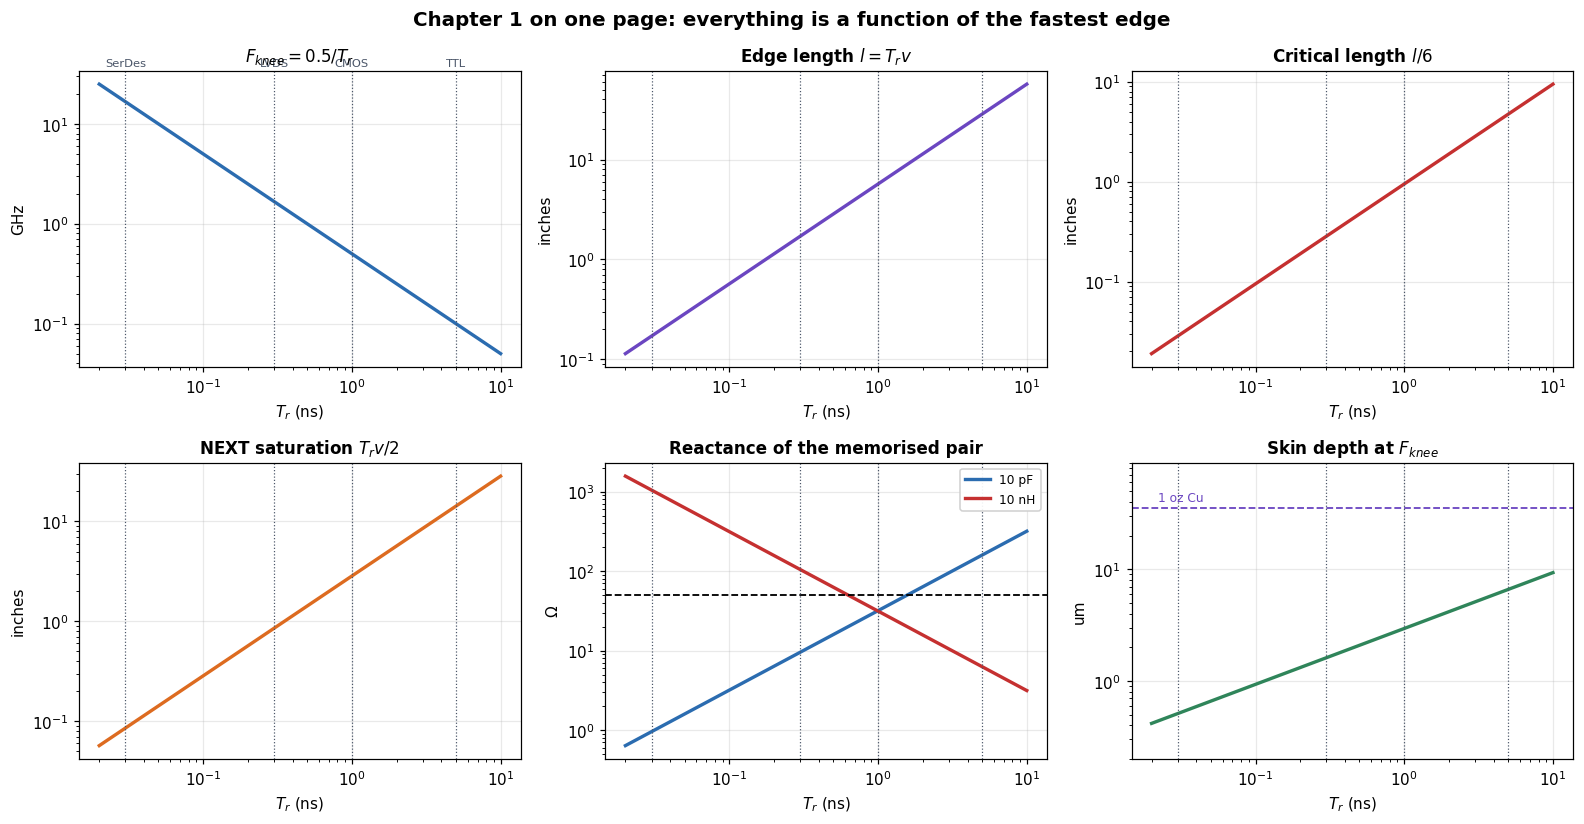

In [35]:
# One dashboard: everything the chapter gives you, as a function of the fastest edge on the board.
trs = np.logspace(np.log10(0.02), np.log10(10), 300)
fig, axes = plt.subplots(2, 3, figsize=(14.5, 7.6))

ax = axes[0][0]
ax.loglog(trs, 0.5/trs, lw=2.2, color=CB)
ax.set_title('$F_{knee} = 0.5/T_r$'); ax.set_ylabel('GHz')

ax = axes[0][1]
ax.loglog(trs, trs*v_stripline, lw=2.2, color=CP)
ax.set_title('Edge length $l = T_r v$'); ax.set_ylabel('inches')

ax = axes[0][2]
ax.loglog(trs, trs*v_stripline/6, lw=2.2, color=CR)
ax.set_title('Critical length $l/6$'); ax.set_ylabel('inches')

ax = axes[1][0]
ax.loglog(trs, trs*v_stripline/2, lw=2.2, color=CO)
ax.set_title('NEXT saturation $T_r v/2$'); ax.set_ylabel('inches')

ax = axes[1][1]
ax.loglog(trs, X_C(10e-12, trs*1e-9), lw=2.2, color=CB, label='10 pF')
ax.loglog(trs, X_L(10e-9, trs*1e-9),  lw=2.2, color=CR, label='10 nH')
ax.axhline(50, color='k', ls='--', lw=1.2)
ax.set_title('Reactance of the memorised pair'); ax.set_ylabel('$\\Omega$'); ax.legend(fontsize=8)

ax = axes[1][2]
ax.loglog(trs, skin_depth(0.5/(trs*1e-9))*1e6, lw=2.2, color=CG)
ax.axhline(t_cu_um, color=CP, ls='--', lw=1.2)
ax.set_ylim(0.2, 90)
ax.text(0.022, t_cu_um*1.15, '1 oz Cu', fontsize=8, color=CP)
ax.set_title('Skin depth at $F_{knee}$'); ax.set_ylabel('um')

MARKS = [('TTL', 5.0), ('CMOS', 1.0), ('LVDS', 0.3), ('SerDes', 0.03)]
for row in axes:
    for ax in row:
        ax.set_xlabel('$T_r$ (ns)')
        for name, tr in MARKS:
            ax.axvline(tr, color=CGY, ls=':', lw=0.8)
for name, tr in MARKS:
    axes[0][0].annotate(name, (tr, 1.0), xycoords=('data', 'axes fraction'),
                        textcoords='offset points', xytext=(0, 3),
                        fontsize=7.5, color=CGY, ha='center')
plt.suptitle('Chapter 1 on one page: everything is a function of the fastest edge',
             fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

---
## Summary of formulas

| Quantity | Expression |
|---|---|
| Knee frequency | $F_{knee} = 0.5/T_r$ |
| 3 dB bandwidth | $F_{3dB} = K/T_r$, $K=0.338$ (Gaussian), $0.350$ (single pole) |
| Rise-time combination | $T_{tot} = \sqrt{\sum_i T_i^2}$ |
| Propagation delay | $D = 85\sqrt{\varepsilon_{r,eff}}$ ps/in |
| Edge length | $l = T_r v = T_r/D$ |
| Lumped criterion | physical size $< l/6$ |
| Capacitive reactance at $F_{knee}$ | $X_C = T_r/(\pi C)$ |
| Inductive reactance at $F_{knee}$ | $X_L = \pi L/T_r$ |
| RC rise time | $T_r = 2.2RC$ |
| Exponential decay time constant | $\tau = \text{Area}/V_0$ |
| Mutual capacitance current | $I_m = C_m\,dV_A/dt$ |
| Capacitive crosstalk | $C_m R_B/T_r$ |
| Mutual inductance voltage | $V_B = L_m\,dI_A/dt$ |
| Inductive crosstalk | $L_m/(R_A T_r)$ |
| Dominance ratio (cap/ind) | $C_m R^2/L_m$, crossover at $\sqrt{L_m/C_m}$ |
| NEXT coefficient | $K_b = \tfrac14(C_m/C + L_m/L)$ |
| FEXT coefficient | $K_f = -\tfrac12(L_m/L - C_m/C)$ |
| NEXT saturation length | $L_{sat} = T_r v/2$ |
| Skin depth | $\delta = \sqrt{\rho/\pi\mu f}$ |
| Dielectric attenuation | $\alpha_d \approx 2.3 f_{GHz}\sqrt{\varepsilon_r}\tan\delta$ dB/in |
| Hammerstad roughness | $K = 1 + \tfrac{2}{\pi}\arctan[1.4(R_q/\delta)^2]$ |

### The three habits

**Bandwidth proxy** — $F_{knee}=0.5/T_r$ from the part's datasheet edge, not the clock.

**Spatial threshold** — delay against $T_r/6$; post the critical length where the layout engineer can
see it.

**Reactance evaluation** — compute $\omega L$ or $1/\omega C$ at $F_{knee}$ and compare against the
surrounding impedance. Negligible there means you can delete it from your mental model with
confidence. Comparable means it is first order and belongs in the simulation.

The inputs to all of this are the transition times of the parts you selected and the physical
dimensions of the board you drew. **Both are known weeks before the first prototype exists.** The cost
of skipping the arithmetic is measured in respins, and respins arrive at the schedule's least
forgiving moment.

---

### Where these estimates expire

Closed forms stop working once geometry becomes genuinely three-dimensional or frequencies push into
the multi-gigahertz range, where non-TEM propagation and complex field interaction break the
analytical approximations. Past there, a 3D full-wave solver plus bench measurement becomes mandatory.
Knowing where your estimate expires is part of the estimate.

For the rigorous multiconductor treatment, the scalar $L$ and $C$ become $N \times N$ matrices solved
through the Telegrapher's equations in matrix form — Clayton Paul, *Analysis of Multiconductor
Transmission Lines*. For loss above a gigahertz, the 2003 follow-on volume, *High-Speed Signal
Propagation: Advanced Black Magic*, is the better reference than the chapter modelled here.